In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib as mpl
import numpy as np
from scipy.interpolate import interp1d
import re
mpl.rcParams['svg.fonttype'] = 'none'
from scipy.optimize import root_scalar
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import glob
import matplotlib.cm as cm
import seaborn as sns
from scipy.stats import gaussian_kde
from math import sqrt, pi
import pickle
from collections import defaultdict
from itertools import product
import gurobipy as gp
from gurobipy import GRB
import itertools

## 시나리오 생성

### 수요 공급선

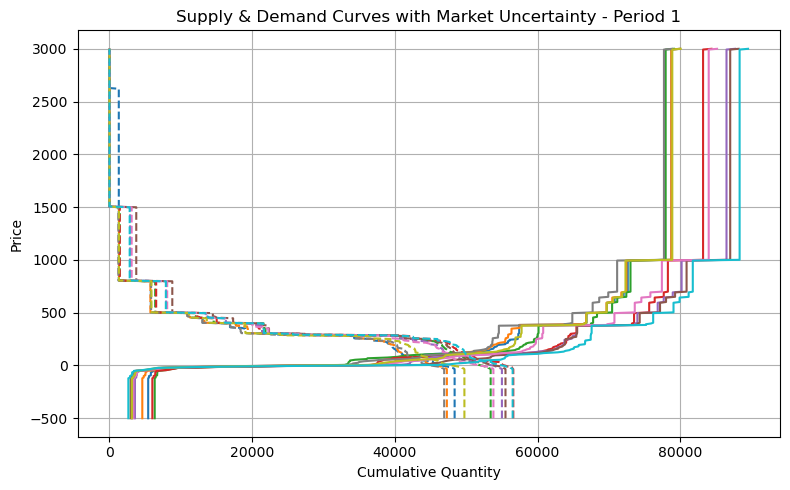

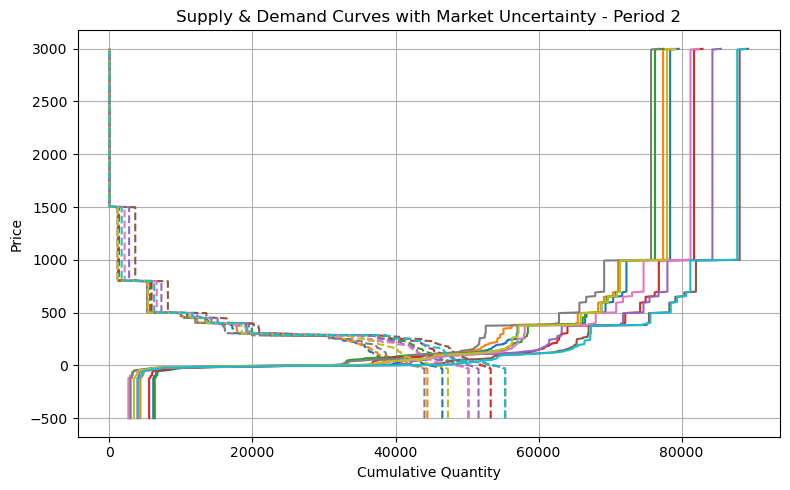

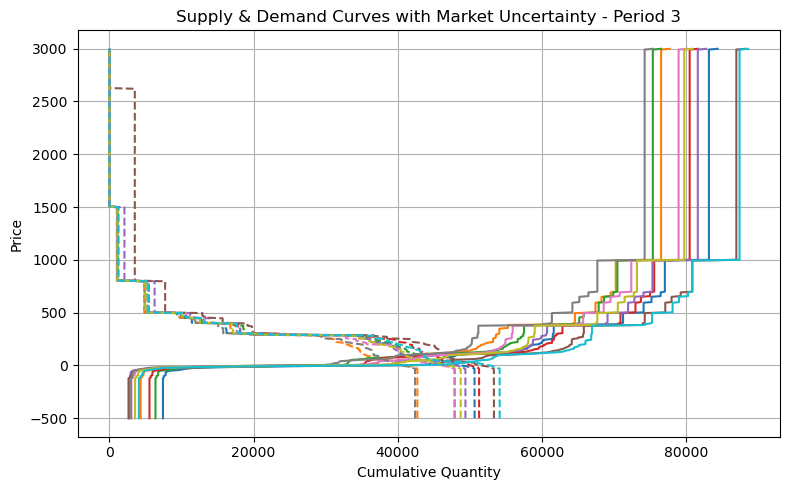

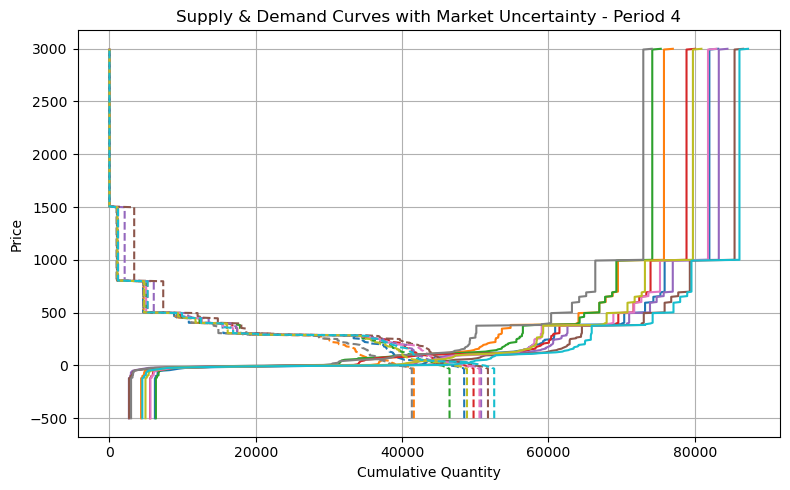

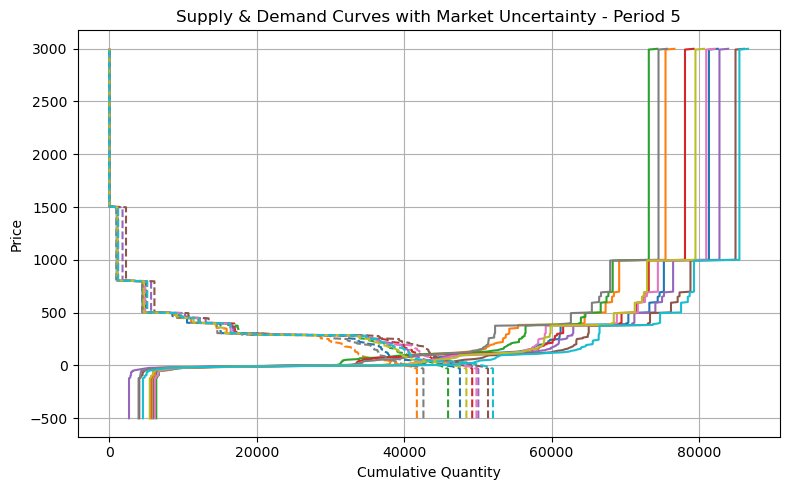

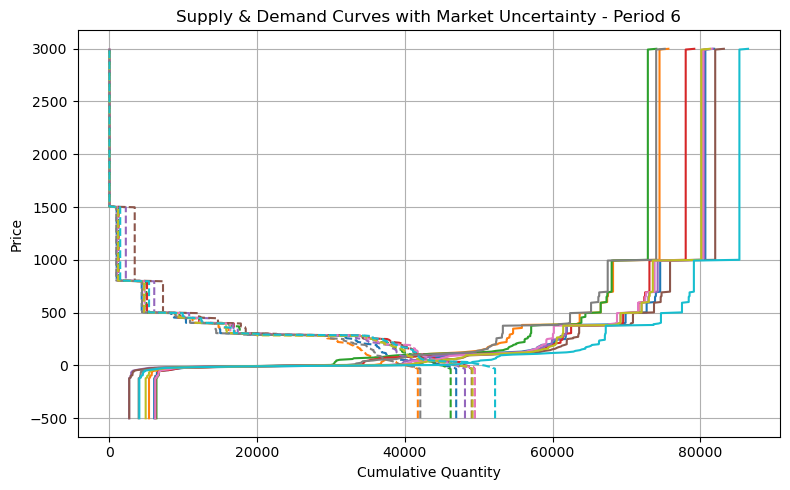

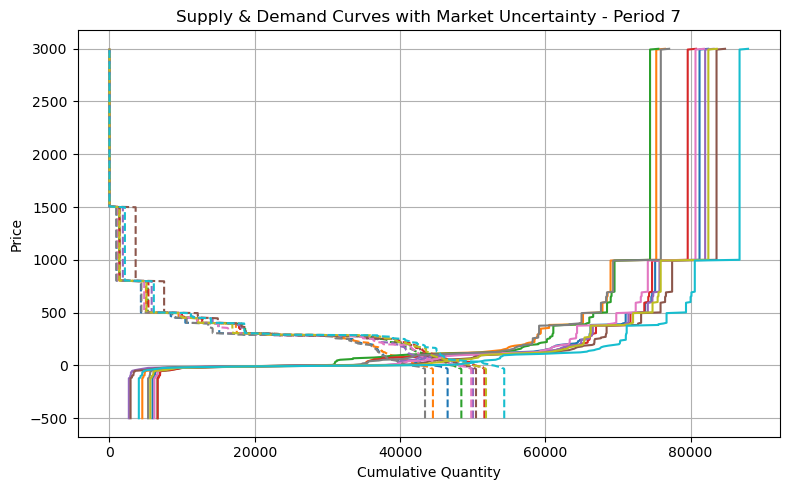

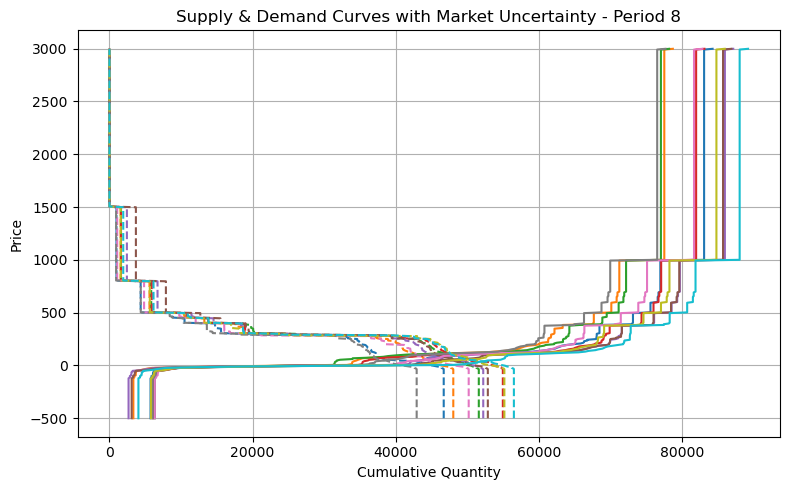

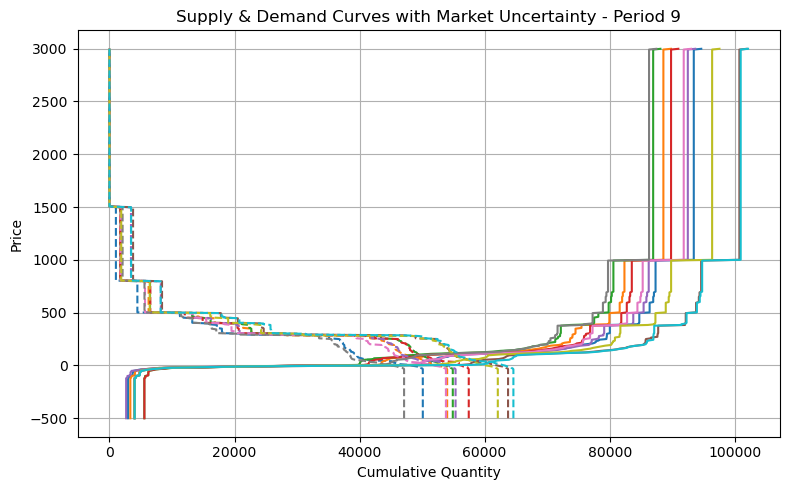

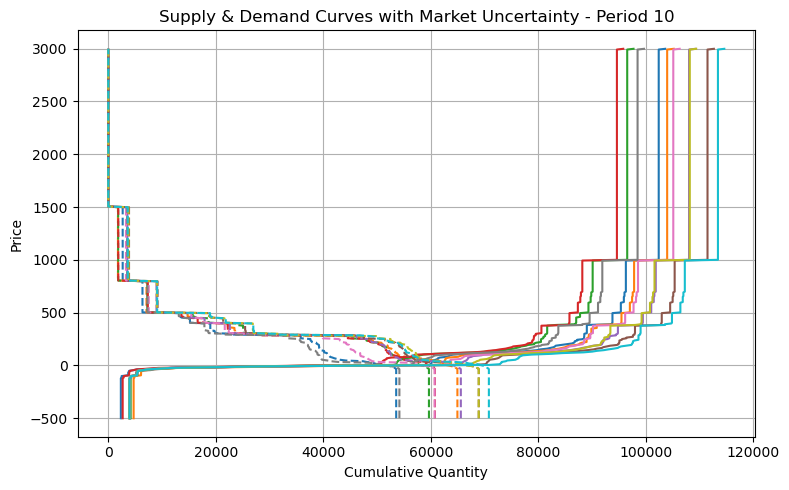

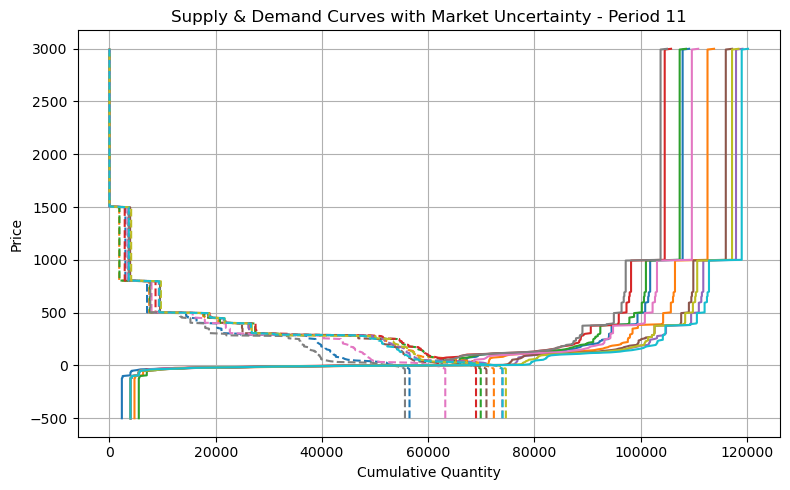

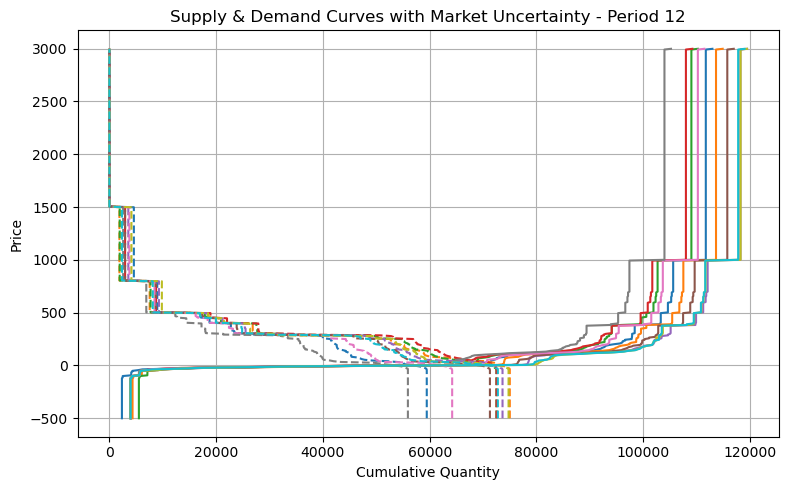

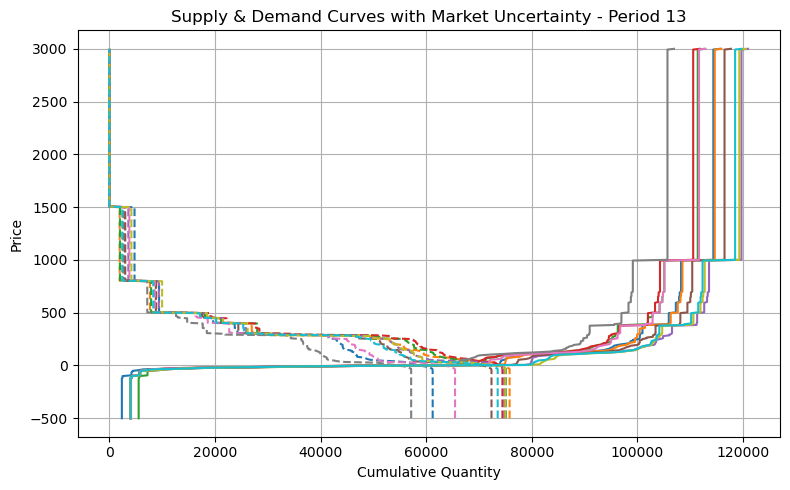

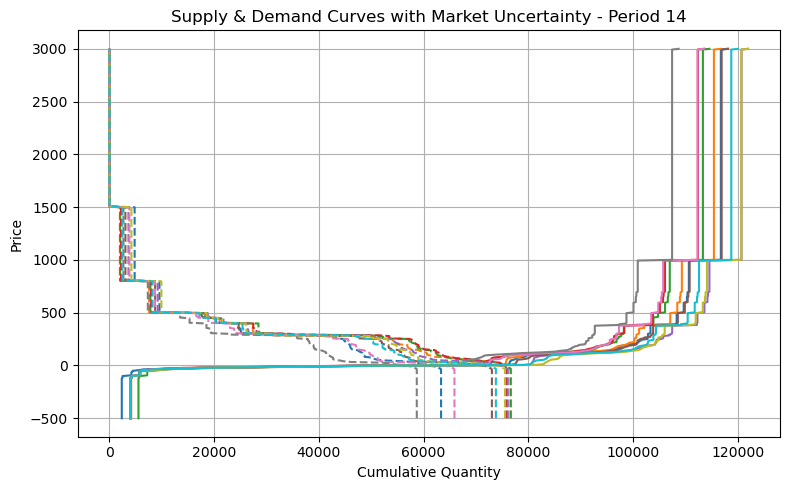

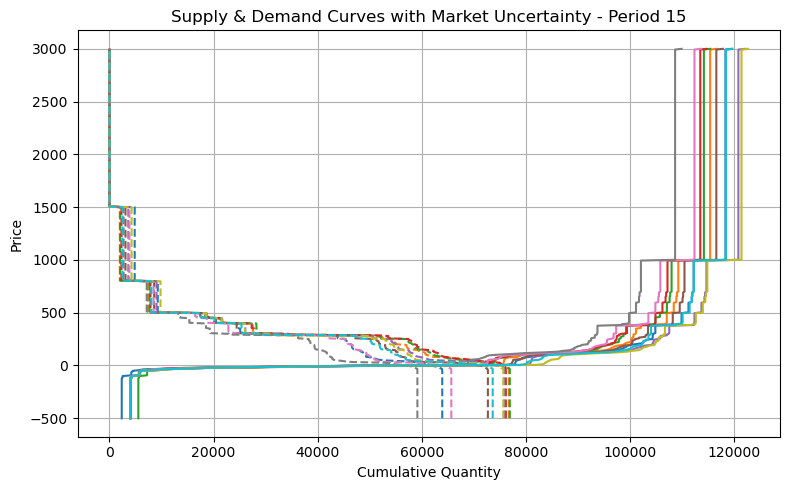

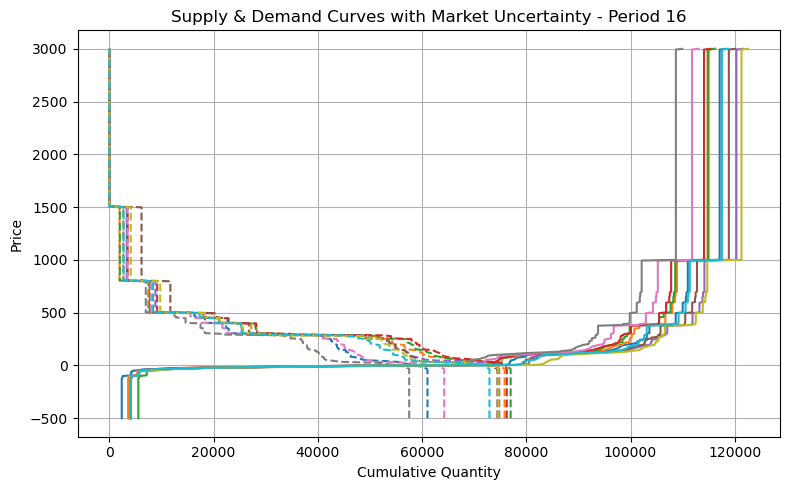

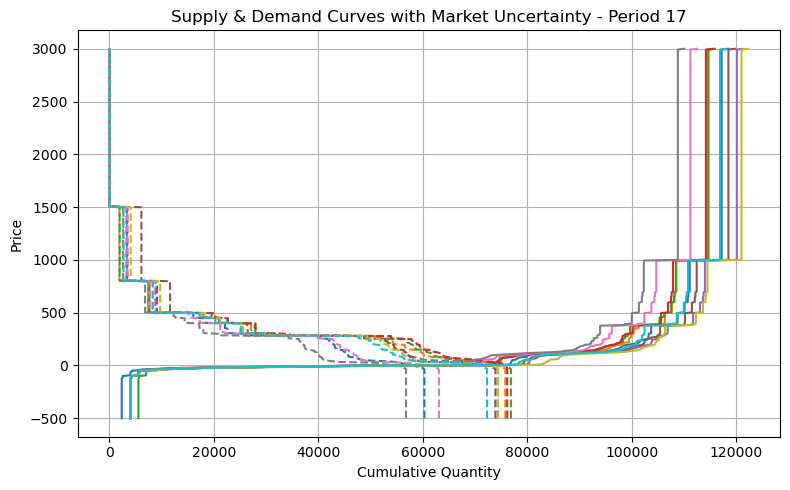

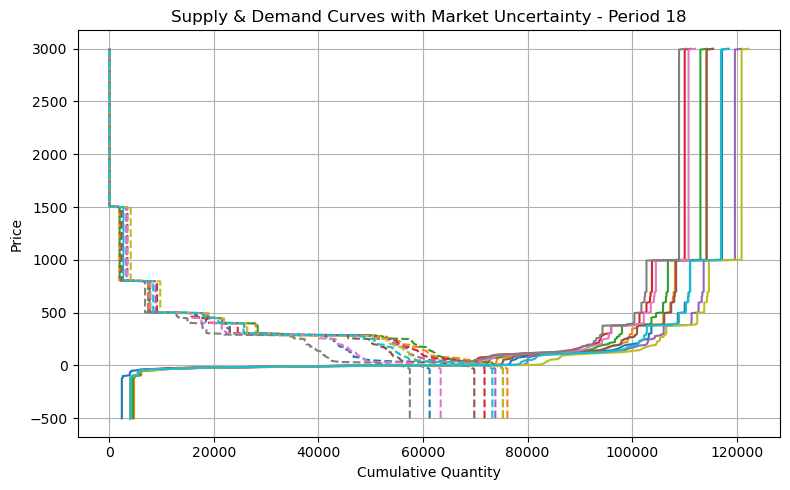

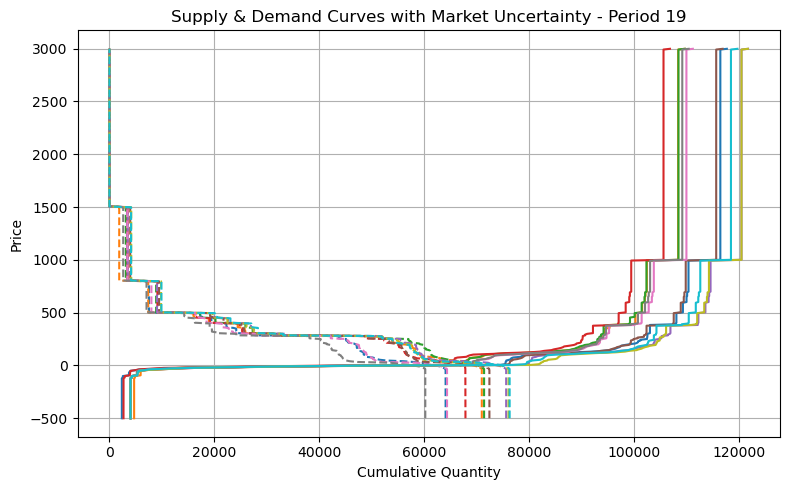

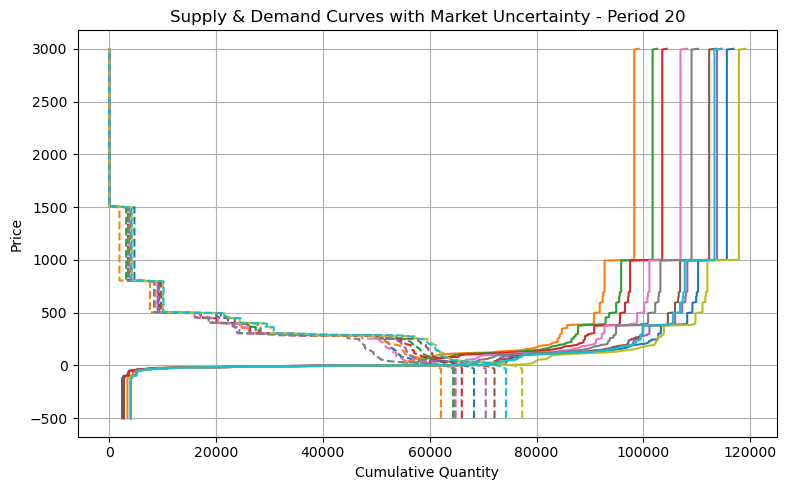

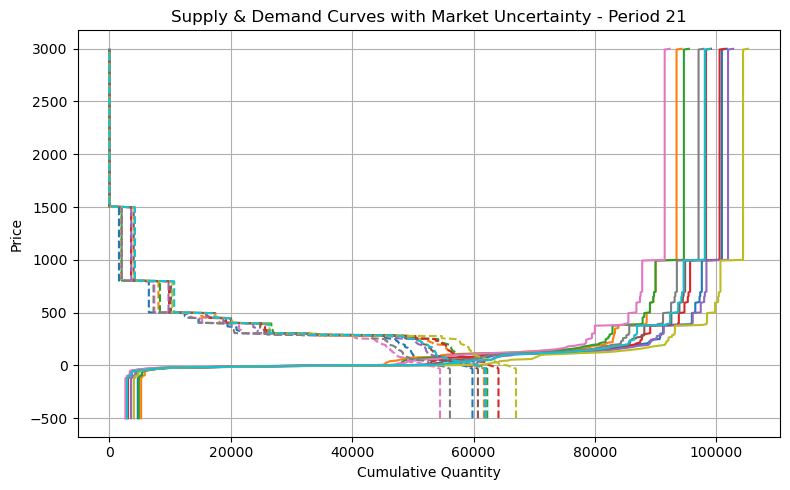

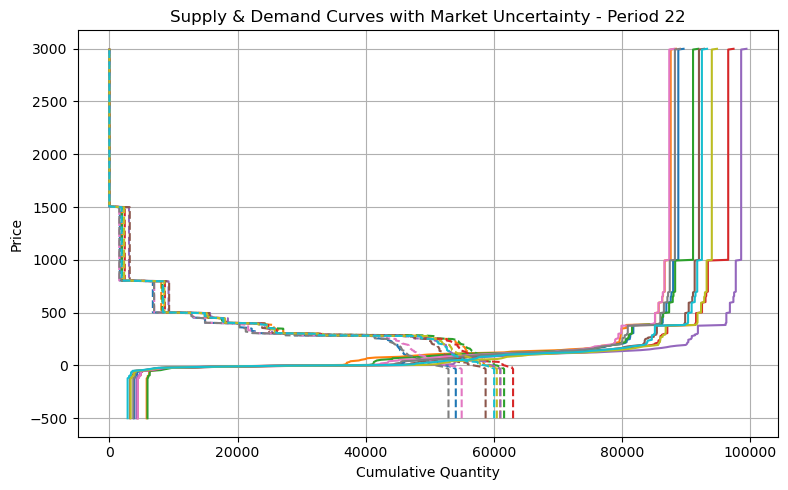

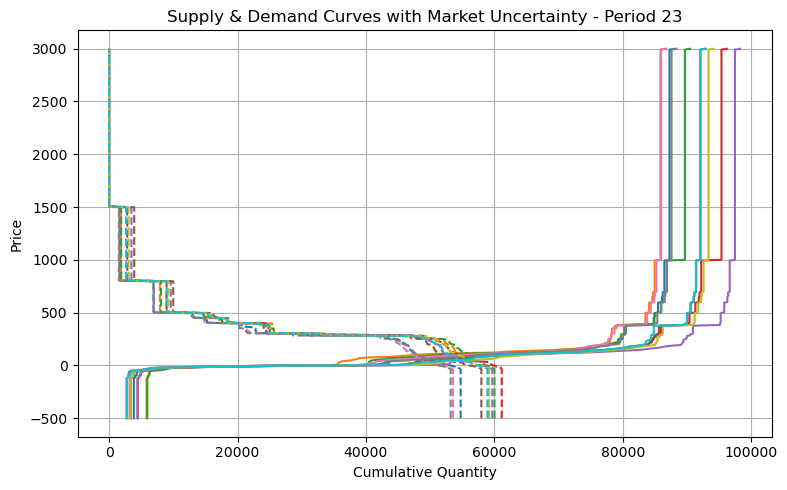

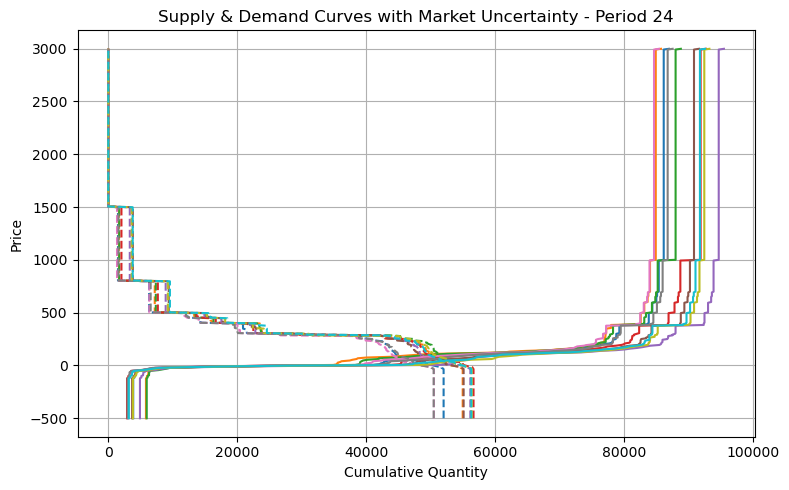

In [22]:
def load_curves_from_path(file_path, period):
    """시나리오 파일 경로 + 시간(period)로 공급/수요 곡선 반환"""
    df = pd.read_csv(file_path, sep=',', encoding='utf-8-sig')

    mask   = df['Time Period'] == period
    supply = df[mask & (df['GC'] == 'V')]
    demand = df[mask & (df['GC'] == 'C')]
    if supply.empty or demand.empty:
        return None

    # 공급 곡선 집계
    s_agg = (supply.groupby('Price')['Amount'].sum()
                   .reset_index().sort_values('Price'))
    s_agg['CumulQty'] = s_agg['Amount'].cumsum()

    # 수요 곡선 집계
    d_agg = (demand.groupby('Price')['Amount'].sum()
                   .reset_index().sort_values('Price'))
    d_agg['CumulQty'] = d_agg['Amount'][::-1].cumsum()[::-1]

    # Price grid 기준 보간
    pmin = min(s_agg['Price'].min(), d_agg['Price'].min())
    pmax = max(s_agg['Price'].max(), d_agg['Price'].max())
    price_grid  = np.linspace(pmin, pmax, 500)

    s_func = interp1d(s_agg['Price'], s_agg['CumulQty'],
                      kind='previous', bounds_error=False,
                      fill_value=(0, s_agg['CumulQty'].iloc[-1]))
    d_func = interp1d(d_agg['Price'], d_agg['CumulQty'],
                      kind='previous', bounds_error=False,
                      fill_value=(d_agg['CumulQty'].iloc[0], 0))

    supply_vals = s_func(price_grid)
    demand_vals = d_func(price_grid)
    return price_grid, supply_vals, demand_vals

# --------------------------
# 날짜별 파일 목록
# --------------------------
days = range(20, 30)
colors = plt.cm.tab10(np.linspace(0,1,len(days)))  # 날짜별 색상 매핑

# --------------------------
# 각 Period(1~24) 마다 플롯
# --------------------------
for period in range(1,25):
    plt.figure(figsize=(8,5))
    any_plotted = False

    for day, color in zip(days, colors):
        date_str = f"202507{day:02d}"
        fn       = f"filteredcurve_{date_str}.csv"

        out = load_curves_from_path(fn, period)
        if out is None:
            continue
        price_grid, supply_vals, demand_vals = out

        plt.plot(supply_vals, price_grid, color=color, lw=1.5, label=f"{date_str} Supply")
        plt.plot(demand_vals, price_grid, color=color, lw=1.5, linestyle="--", label=f"{date_str} Demand")
        any_plotted = True

    if not any_plotted:
        print(f"{period}시: 데이터 없음")
        plt.close()
        continue

    plt.xlabel("Cumulative Quantity")
    plt.ylabel("Price")
    plt.title(f"Supply & Demand Curves with Market Uncertainty - Period {period}")
    plt.grid(True)
    # plt.legend(fontsize=8, loc="best", ncol=2)
    plt.tight_layout()
    plt.show()


### RDC

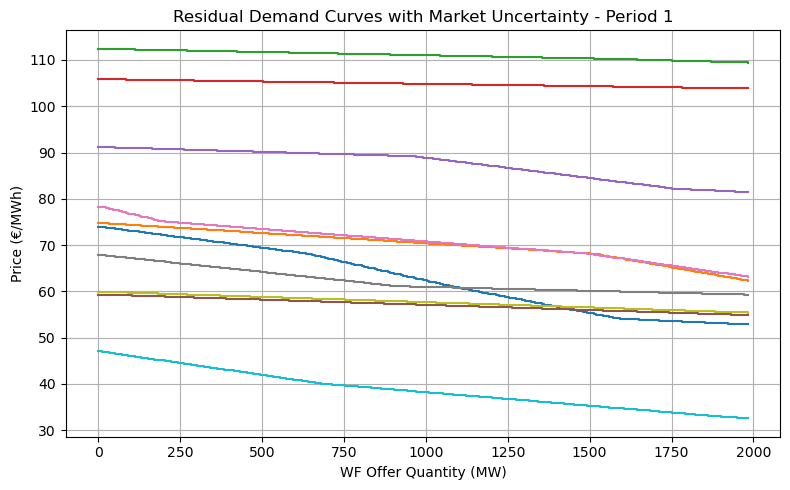

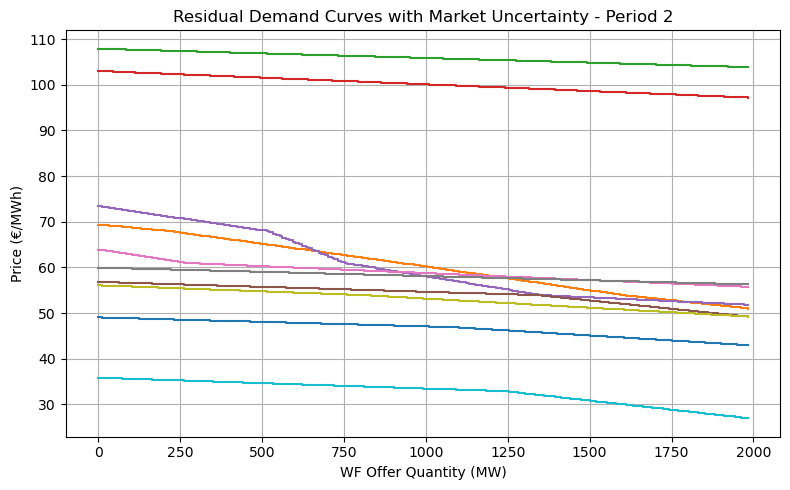

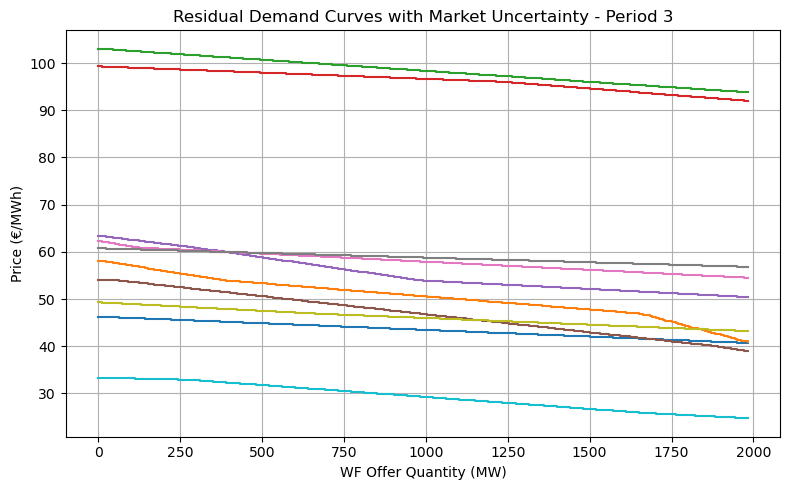

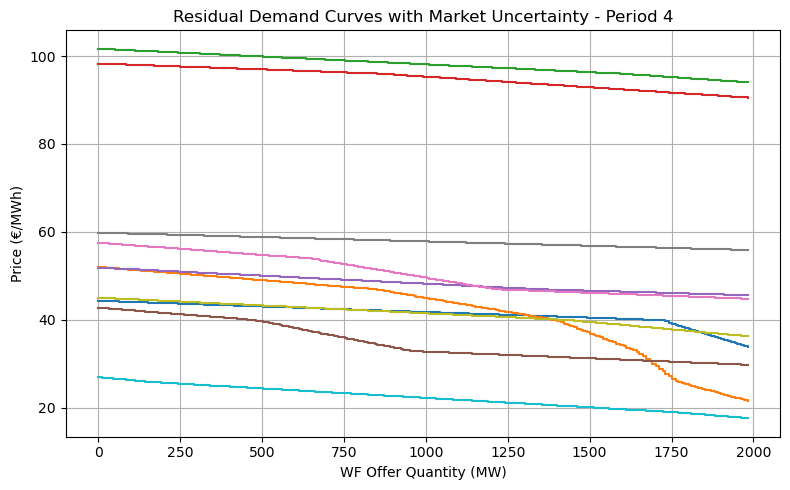

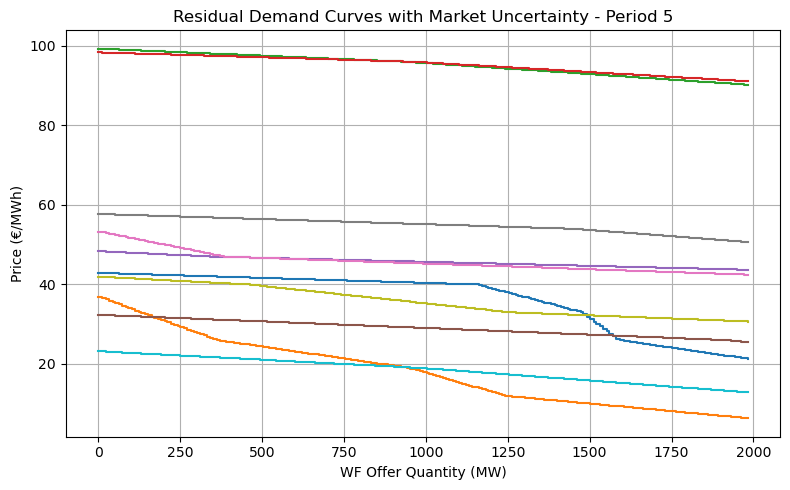

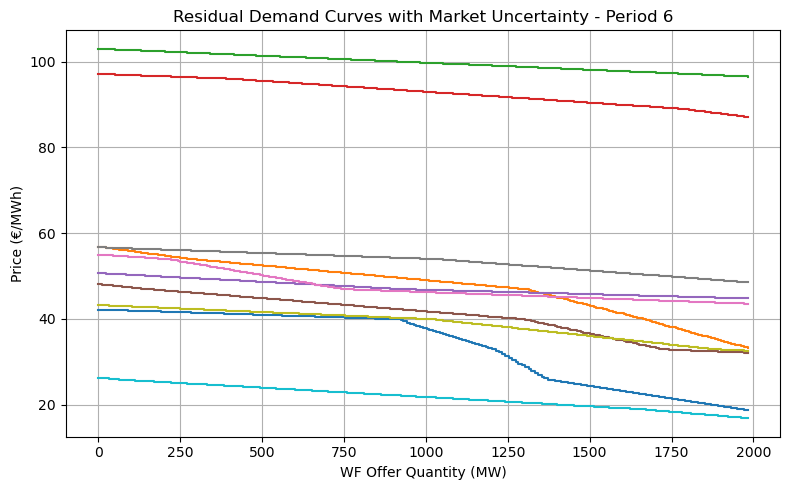

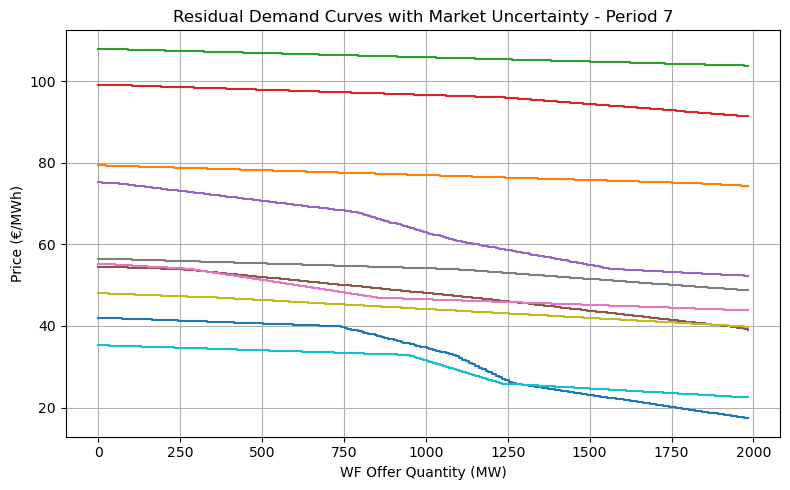

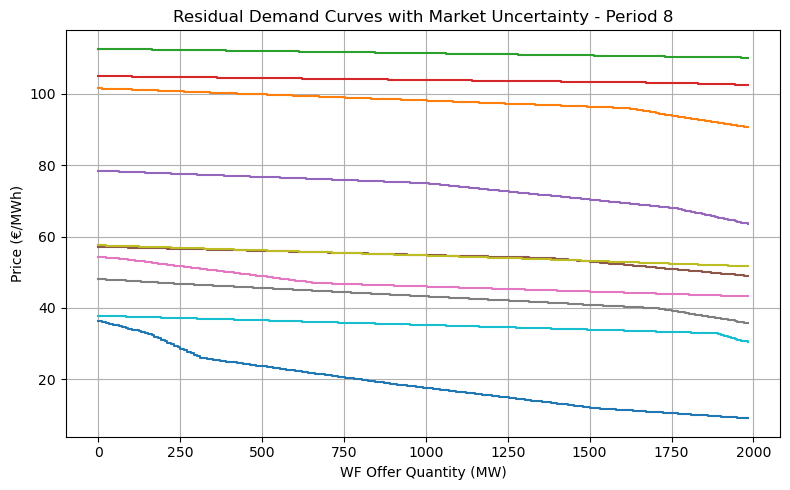

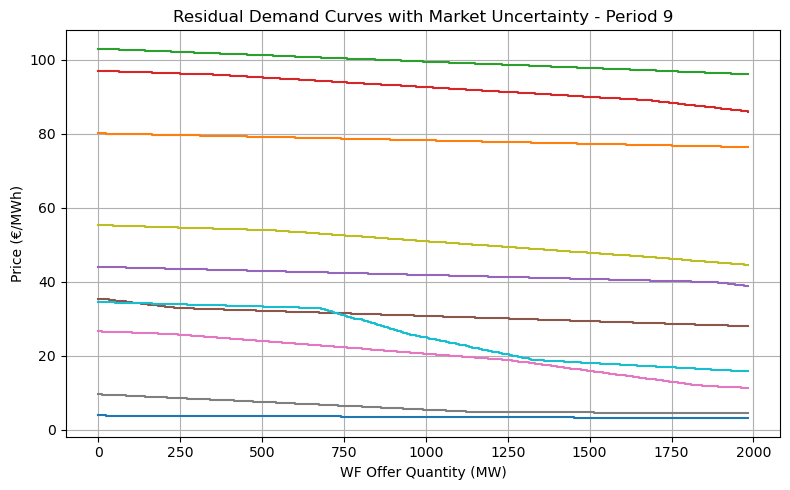

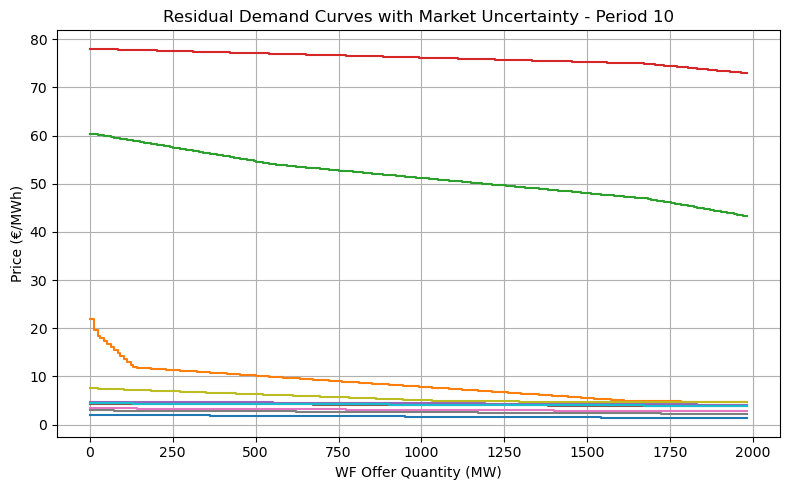

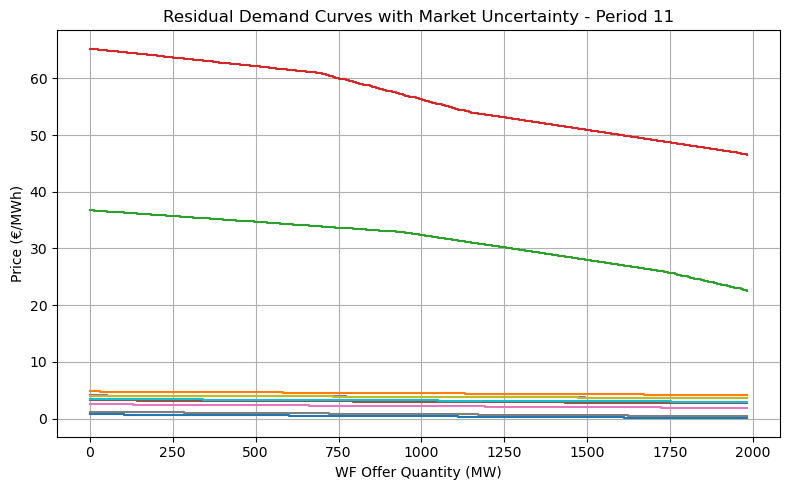

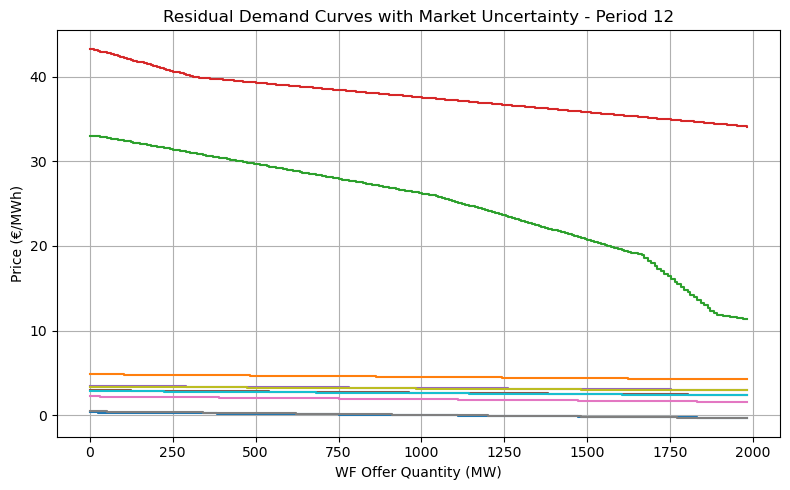

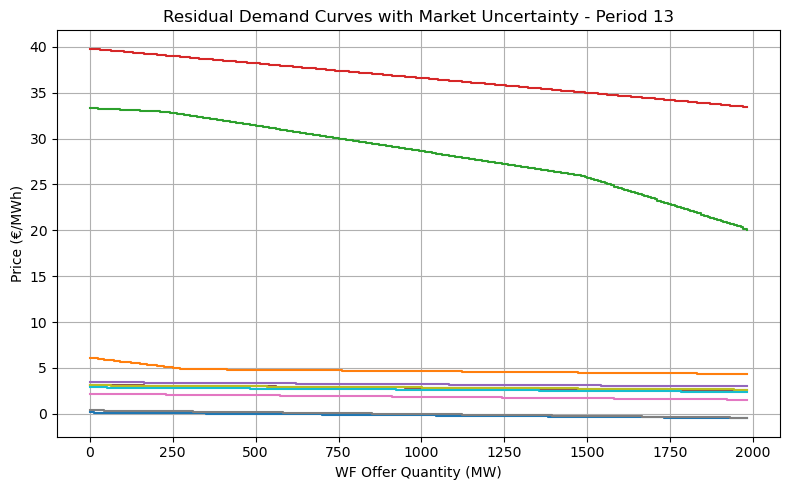

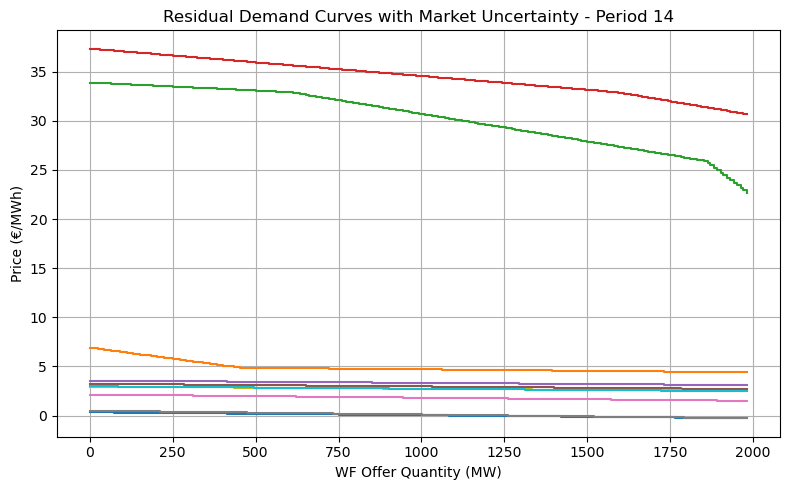

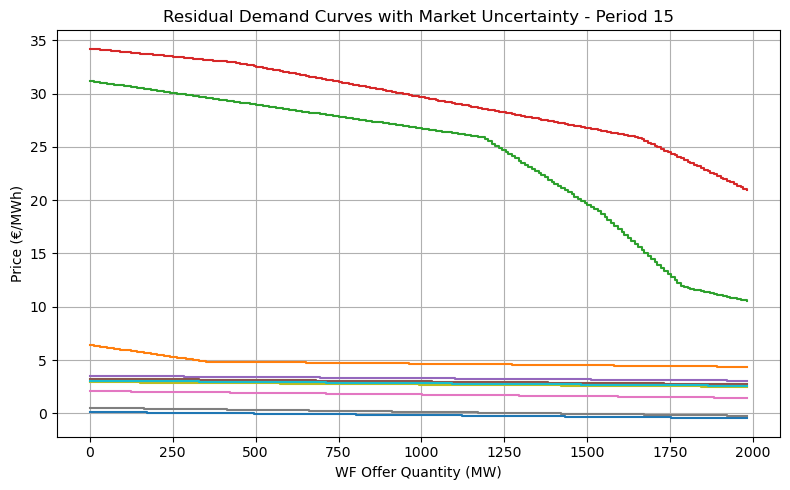

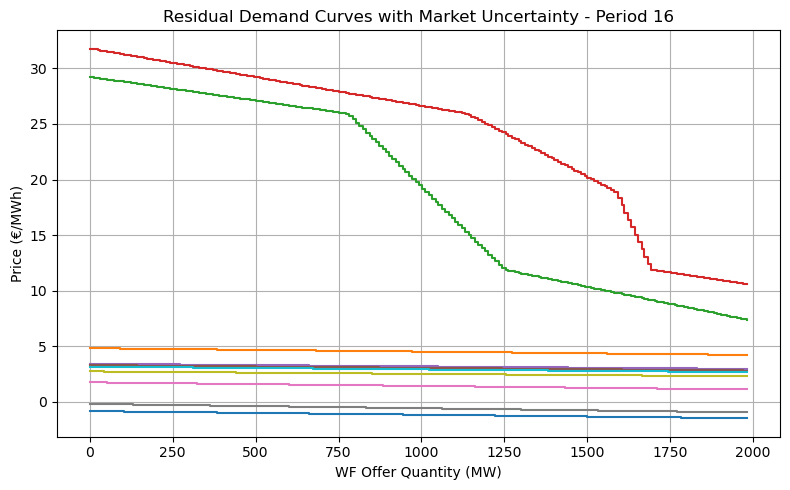

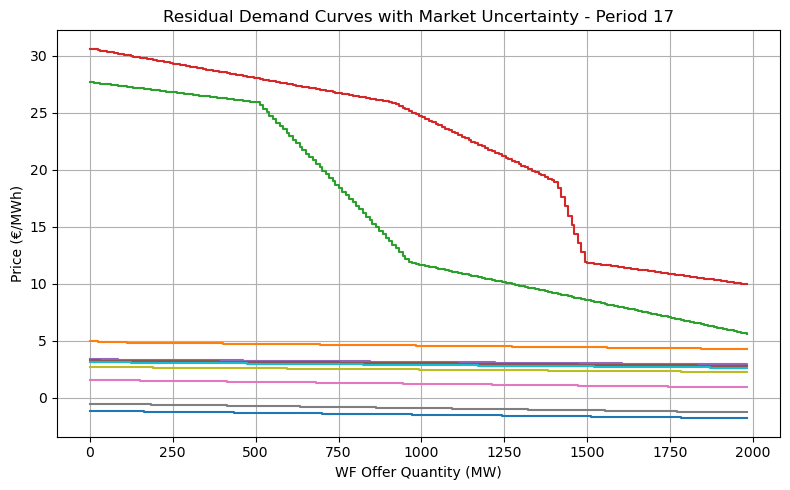

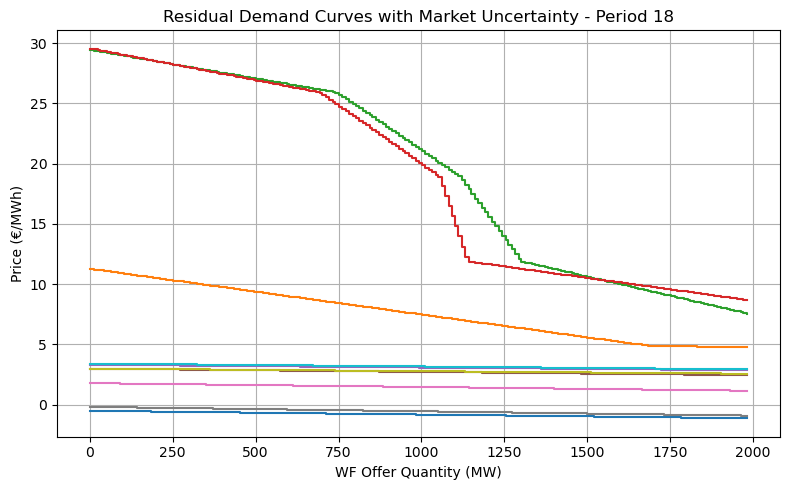

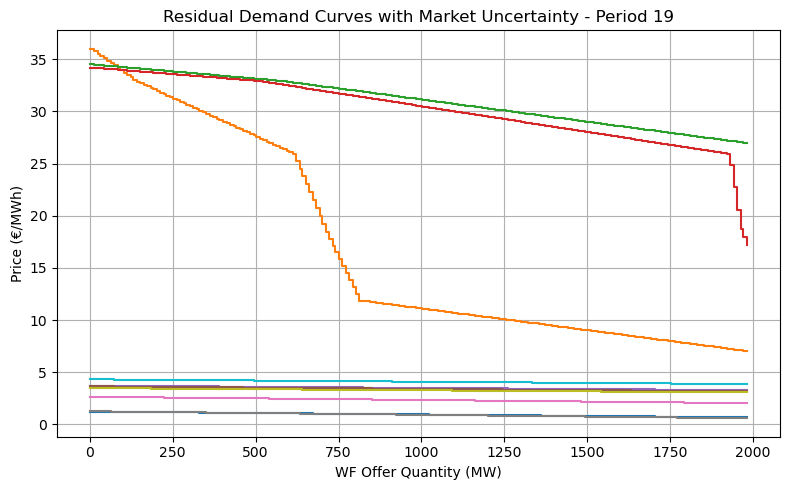

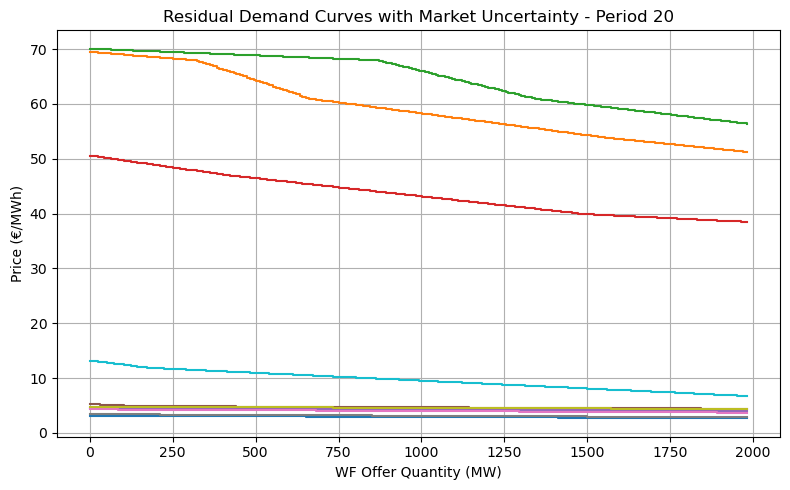

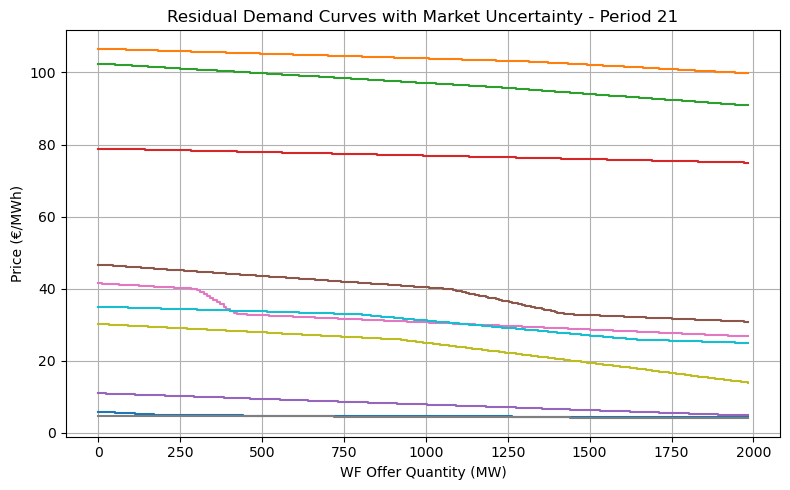

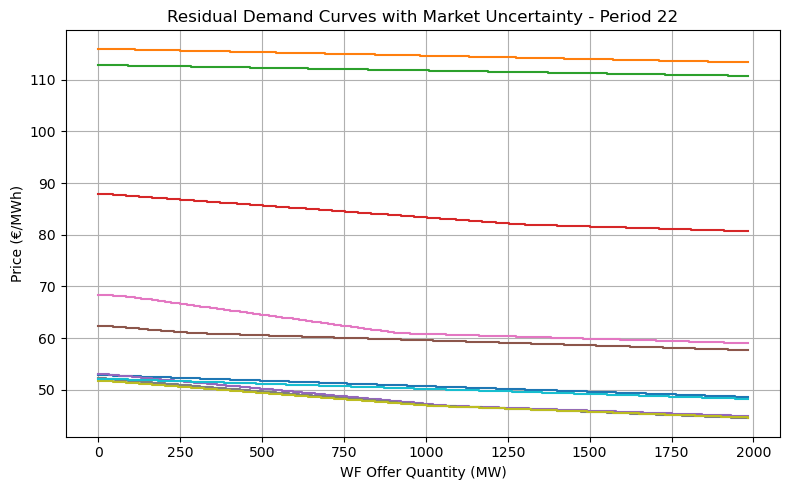

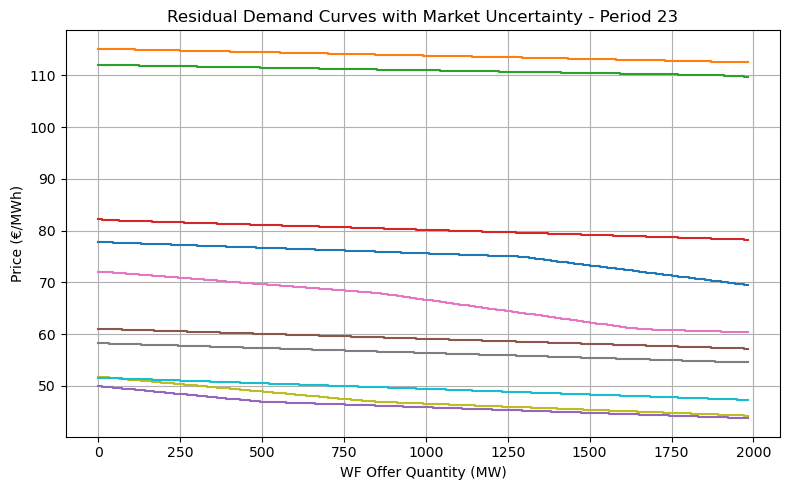

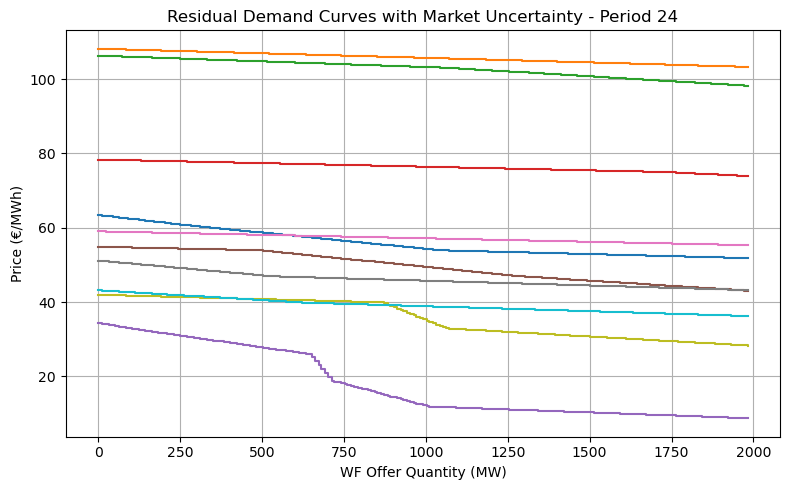

In [50]:
# --- RDC 계산 함수 ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0,p1 = price_grid[i], price_grid[i+1]
            r0,r1 = resid[i], resid[i+1]
            if r1!=r0:
                p_star = p0 - r0*(p1-p0)/(r1-r0)
                rdc.append((q,p_star))
    return rdc


# --- 공통 설정 ---
# days          = range(20,29)   # 2025-07-20 ~ 2025-07-27
wf_offer_grid = np.arange(0, 2000, 10)
B             = 500   # stepwise block 수
colors        = plt.cm.tab10(np.linspace(0,1,len(days)))

# stepwise 파라미터 저장용 dict
qini            = {}
qmax            = {}
lambda_da_block = {}
orig_cp         = {}

# --- 시간대별 Figure 하나씩 ---
for period in range(1,25):

    plt.figure(figsize=(8,5))

    for day, color in zip(days, colors):
        date_str = f"202507{day:02d}"
        scen_name = f"day{day}"  # 파일명 대신 날짜 표시용
        fn        = f"filteredcurve_{date_str}.csv"

        if not os.path.exists(fn):
            print(f"파일 없음: {fn}")
            continue

        df  = pd.read_csv(fn, encoding='utf-8-sig')

        sub = df[df['Time Period']==period]
        sup = sub[sub['GC']=='V']
        dem = sub[sub['GC']=='C']
        if sup.empty or dem.empty:
            continue

        # 공급/수요 집계
        s_agg = sup.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
        s_agg['Cumul'] = s_agg['Amount'].cumsum()

        d_agg = dem.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
        d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

        # 보간
        s_f = interp1d(s_agg['Price'], s_agg['Cumul'],
                       kind='previous', bounds_error=False,
                       fill_value=(0, s_agg['Cumul'].iat[-1]))
        d_f = interp1d(d_agg['Price'], d_agg['Cumul'],
                       kind='previous', bounds_error=False,
                       fill_value=(d_agg['Cumul'].iat[0], 0))

        pg = np.linspace(min(s_agg['Price'].min(), d_agg['Price'].min()),
                         max(s_agg['Price'].max(), d_agg['Price'].max()), 500)
        sv = s_f(pg); dv = d_f(pg)
        # 교차점(시장 균형가격) 계산
        def resid0(p):
            return d_f(p) - s_f(p)
        sol0 = root_scalar(resid0, bracket=[pg[0], pg[-1]], method='bisect')
        orig_cp[(date_str, period)] = sol0.root if sol0.converged else np.nan

        # RDC 계산
        rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
        if not rdc_pts:
            continue
        qv, pv = zip(*rdc_pts)

        # stepwise 블록 경계 만들기
        q_breaks = np.linspace(min(qv), max(qv), B+1)

        for b in range(B):
            q_low, q_high = q_breaks[b], q_breaks[b+1]
            mask = (np.array(qv) >= q_low) & (np.array(qv) < q_high)
            if not mask.any():
                continue
            # 블록 내 대표값
            qini[(scen_name, period, b)] = q_low
            qmax[(scen_name, period, b)] = q_high - q_low
            lambda_da_block[(scen_name, period, b)] = np.mean(np.array(pv)[mask])

        # --- Stepwise 근사 곡선 플롯 ---
        q_step = [q_breaks[0]]
        p_step = [lambda_da_block[(scen_name, period, 0)]]

        for b in range(B):
            if (scen_name, period, b) not in lambda_da_block:
                continue
            q_high = q_breaks[b+1]
            lam    = lambda_da_block[(scen_name, period, b)]
            q_step.extend([q_high])
            p_step.extend([lam])
        
        plt.step(q_step, p_step, where="post", lw=1.5,
                 color=color, label=f"{scen_name} stepwise")

    # 시간대별 제목
    hh1 = f"{period-1:02d}:00"; hh2 = f"{period%24:02d}:00"
    plt.title(f"Residual Demand Curves with Market Uncertainty - Period {period}")

    plt.xlabel("WF Offer Quantity (MW)")
    plt.ylabel("Price (€/MWh)")
    plt.grid(True)
    # plt.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

In [7]:
# # --- 1) DataFrame 만들기 ---
# df = pd.DataFrame([
#     {
#         "scenario": scen,   # scen_name 대신 date_str (예: "20250720")
#         "t": t,
#         "b": b,
#         "qini": qini[(scen,t,b)],
#         "qmax": qmax[(scen,t,b)],
#         "lam_da": lambda_da_block[(scen,t,b)]
#     }
#     for (scen,t,b) in qini.keys()
# ])

# df = df.sort_values(["scenario","t","b"]).reset_index(drop=True)

# # 저장
# df.to_csv("rdc_scenarios0919.csv", index=False, encoding="utf-8-sig")
# print("✅ rdc_scenarios0919.csv 저장 완료!")


# --- 2) 불러오기 ---
df = pd.read_csv("rdc_scenarios0919.csv", encoding="utf-8-sig")

# 날짜별 scenario 리스트
date_range = df["scenario"].unique().tolist()   # ["20250720","20250721",...]
S = list(range(len(date_range)))                # 시나리오 index
T = list(range(1, 25))                          # 시간
I = [0]
J = [1,2,3,4]
Δt = 0.25
rho = {s: 1/len(S) for s in S}                  # 균등 확률

# 시나리오 문자열(날짜) → 숫자 index 매핑
s_map = {date: idx for idx, date in enumerate(date_range)}

# --- 3) 최종 dict 구성 ---
qini_scen_final      = {}
qmax_scen_final      = {}
lambda_da_scen_final = {}
valid_blocks         = {t: [] for t in T}

for (s,t), sub in df.groupby(["scenario","t"]):
    sub_sorted = sub.sort_values("qini").reset_index(drop=True)
    for b, r in sub_sorted.iterrows():
        s_idx = s_map[s]   # "20250720" → 0, "20250721" → 1, ...
        qini_scen_final[(t,b,s_idx)]      = float(r["qini"])
        qmax_scen_final[(t,b,s_idx)]      = float(r["qmax"])
        lambda_da_scen_final[(t,b,s_idx)] = float(r["lam_da"])
        if r["qmax"] > 0:
            valid_blocks[t].append(b)

# 중복 제거
valid_blocks = {t: sorted(set(bs)) for t, bs in valid_blocks.items()}

print("예시 qini_scen_final keys:", list(qini_scen_final.keys())[:10])
print("예시 valid_blocks[1]:", valid_blocks[1])

예시 qini_scen_final keys: [(1, 0, 0), (1, 1, 0), (1, 2, 0), (1, 3, 0), (1, 4, 0), (1, 5, 0), (1, 6, 0), (1, 7, 0), (1, 8, 0), (1, 9, 0)]
예시 valid_blocks[1]: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190

### 발전량, RT 가격 시나리오 생성

In [3]:
S = list(range(10))                                     # 풍력 설비 0번만
I = list(range(1))                                     # 풍력 설비 0번만
T = list(range(1, 25))                                # 시간 1~24
J = [1,2,3,4]

In [4]:
# 15분 분할
#7월 20일 기준
rt_price_15min = [
    75.78, 75.54, 72.72, 42.23, 75.30, 75.30, 61.91, 35.25, 75.30, 48.33,
    39.81, 23.08, 65.80, 49.92, 33.81, 18.07, 45.68, 35.81, 26.04, 30.98,
    32.11, 36.47, 34.14, 29.49, 27.58, 34.34, 21.44, 33.44, 26.00,  3.30,
    -1.99, -8.99, 28.79,  0.49, -5.51, -6.31,  3.52,  0.65, -1.01, -5.90,
    -0.97, -3.00, -3.00,  0.00,  0.01,  4.31,  0.00,  0.00,  0.99,  0.99,
     0.14,  0.00,  0.65,  0.65,  0.65,  0.00,  0.99,  0.00,  0.00,  0.00,
    -0.65, -0.65, -0.50, -0.65,  0.00,  0.00,  0.00, -0.01, -0.61,  0.00,
     0.00,  0.00,  0.00,  0.00,  0.00,  0.00, -9.70, -0.97, 20.33, 79.89,
    -8.99,  8.81, 49.88, 83.87, 36.84, 66.60, 72.19, 75.54, 82.80, 82.80,
    85.21, 82.01, 86.16, 78.72, 72.27, 53.31
]
rt_price_15min = 0.4 * np.array(rt_price_15min)  # 15분 단위 RT 가격
# 1) 15분 가격을 (24시간 × 4구간) 배열로 재형성
rt15_arr = np.array(rt_price_15min).reshape(24, 4)

# (t,j) → price 사전 생성
#  t=1..24,  j=1..4
lambda_rt = {
    (t, j): float(rt15_arr[t-1, j-1])
    for t in T for j in J
}
sigma_eta = 0.1  # 실시간 가격 변동성 (5%)
# λ_rt_act[(t,j,s)] : 시나리오 s의 시간 t, 구간 j 실시간 가격
lambda_rt_act = {
    (t, j, s): rt15_arr[t-1, j-1] * (1 + sigma_eta * np.random.randn())
    for t in T for j in J for s in S
}

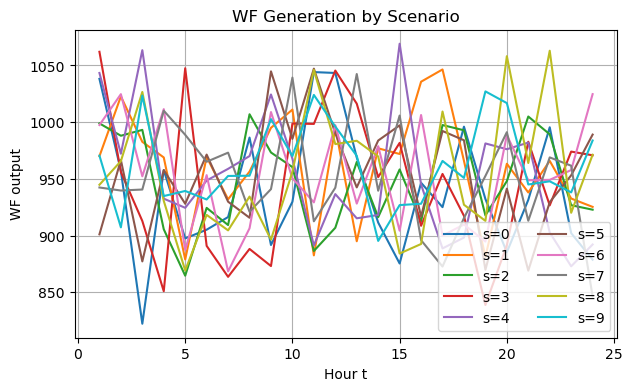

[CHECK] RT act min/max: -4.66 / 41.60,  negatives: 180개
[CHECK] WF  min/max/mean: 822.4 / 1069.2 / 952.4


In [5]:
sigma_frac = 0.05   # 5% 변동성
mu_frac    = 0.95   # 평균 95% 정격출력
Cw = 1000

np.random.seed(0)
pwf = {
    (i,t,s): max(0, np.random.normal(Cw*mu_frac, Cw*sigma_frac))
    for i in I for t in T for s in S
}

i0 = I[0]
fig4 = plt.figure(figsize=(7,4))
for s in S:
    wf_t = [pwf[(i0,t,s)] for t in T]
    plt.plot(T, wf_t, label=f"s={s}")
plt.title('WF Generation by Scenario')
plt.xlabel('Hour t')
plt.ylabel('WF output')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

# --- 5) 빠른 통계/이상치 점검 ---
rt_all = np.array([lambda_rt_act[(t,j,s)] for t in T for j in J for s in S])
wf_all = np.array([pwf[(i0,t,s)] for t in T for s in S])

neg_rt = np.sum(rt_all < 0)
print(f"[CHECK] RT act min/max: {rt_all.min():.2f} / {rt_all.max():.2f},  negatives: {neg_rt}개")
print(f"[CHECK] WF  min/max/mean: {wf_all.min():.1f} / {wf_all.max():.1f} / {wf_all.mean():.1f}")


### 시나리오 튜플 생성

In [8]:
# ----------------------------
# 1) 1000개 조합의 w 인덱스 만들기
# ----------------------------
triples = list(product(S, S, S))   # (rdc_s, gen_s, rt_s) 10*10*10 = 1000
W = list(range(len(triples)))      # w = 0..999
rho_w = [1/len(W)] * len(W)
# ----------------------------
# 2) (t,b,w) / (i,t,w) / (t,j,w) 빅 딕셔너리 생성
# ----------------------------

qini_big      = {}
qmax_big      = {}
lambda_da_big = {}
pwf_big       = {}
rt_big        = {}

# w별 유효 블록 (t,b) 집합도 함께 구축 (b가 없는 경우 KeyError 방지)
valid_blocks_by_w = defaultdict(list)   # key: (t,w) -> [b1,b2,...]

for w, (rdc_s, gen_s, rt_s) in enumerate(triples):
    # --- RDC: (t,b,rdc_s) -> (t,b,w)
    for (t,b,s) in qini_scen_final.keys():
        if s != rdc_s:
            continue
        qini_big[(t,b,w)]      = qini_scen_final[(t,b,s)]
        qmax_big[(t,b,w)]      = qmax_scen_final[(t,b,s)]
        lambda_da_big[(t,b,w)] = lambda_da_scen_final[(t,b,s)]
        # qmax>0인 블록만 유효 블록에 추가 (원래 valid_blocks[t]와 일치하게)
        if qmax_big[(t,b,w)] > 0:
            valid_blocks_by_w[(t,w)].append(b)

    # --- WF: (i,t,gen_s) -> (i,t,w)
    for (i,t,s) in pwf.keys():
        if s != gen_s:
            continue
        pwf_big[(i,t,w)] = pwf[(i,t,s)]

    # --- RT: (t,j,rt_s) -> (t,j,w)
    for (t,j,s) in lambda_rt_act.keys():
        if s != rt_s:
            continue
        rt_big[(t,j,w)] = lambda_rt_act[(t,j,s)]

# 중복 제거 및 정렬
for (t,w), bs in list(valid_blocks_by_w.items()):
    valid_blocks_by_w[(t,w)] = sorted(set(bs))

print("W 개수:", len(W))                      # 1000
print("예시 lambda_da_big key:", next(iter(lambda_da_big)))
print("예시 rt_big key:", next(iter(rt_big)))


W 개수: 1000
예시 lambda_da_big key: (1, 0, 0)
예시 rt_big key: (1, 1, 0)


## 최적화 모델: stochastic RDC

In [9]:
eta_c, eta_d    = 0.9, 0.9
E0, E_min, E_max = 1400, 500, 2250
pc_max, pd_max  = 500, 500
Δt = 0.25

In [10]:
model = gp.Model("WF_ESS_3D_RDC_RT_WF")

# ---------- 1단계(H&N) ----------
u = model.addVars([(t,b) for t in T for b in valid_blocks[t]],
                  vtype=GRB.BINARY, name="u")

# qvar, p_bid도 w에 종속(DA 기대값을 w로 평균)
qvar  = model.addVars([(t,b) for t in T for b in valid_blocks[t]],
                      lb=0.0, name="qvar")
p_bid = model.addVars(T, lb=0.0, name="p_bid")

# ESS on/off (H&N)
u_c = model.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_c")
u_d = model.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_d")

# ---------- 2단계(Recourse; w별) ----------
p_c = model.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=0.0, ub=pc_max, name="p_c")
p_d = model.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=0.0, ub=pd_max, name="p_d")
E_q = model.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=E_min, ub=E_max, name="E_q")
p_b = model.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=0.0, name="p_b")

# LDR 계수(공통)
p_hat_c = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_c")
p_hat_d = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_d")
D_c     = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_c")
D_d     = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_d")

# ---------- 목적함수 ----------
# DA 수익
DA_rev = gp.quicksum(
    rho_w[w] * gp.quicksum(
        lambda_da_big[(t,b,w)] * (u[t,b] * qini_big[(t,b,w)] + qvar[t,b])
        for b in valid_blocks_by_w.get((t,w), [])
        if (t,b,w) in lambda_da_big
    )
    for w in W for t in T
)

# RT 수익
RT_rev = gp.quicksum(
    rho_w[w] * gp.quicksum(
        rt_big[(t,j,w)] * (p_b[t,j,w] - p_bid[t]/4.0)
        for j in J if (t,j,w) in rt_big
    )
    for w in W for t in T
)

model.setObjective(DA_rev + RT_rev, GRB.MAXIMIZE)

Set parameter Username
Set parameter LicenseID to value 2665974
Academic license - for non-commercial use only - expires 2026-05-14


In [22]:
# ---------- 제약식 (통일 버전) ----------
# 모든 (t,j,w)에 대해 균형
for w in W:
    for t in T:
        for j in J:
            model.addConstr(
                p_b[(t,j,w)] ==
                (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0)   # 15분 평균 풍력
                + p_d[(t,j,w)] - p_c[(t,j,w)]                    # ESS 순발전
                - p_bid[t]/4.0,                                  # DA 약속의 1/4
                name=f"rt_balance_{t}_{j}_w{w}"
            )
# (6c) 매 시각 블록 하나 선택 (1단계 공통)
for t in T:
    model.addConstr(gp.quicksum(u[t,b] for b in valid_blocks[t]) == 1,
                    name=f"one_block_{t}")

# (6d) qvar ≤ qmax * u  (모든 w에서 성립 → qmax_big[(t,b,w)] 사용, qvar은 w-비의존)
for w in W:
    for t in T:
        for b in valid_blocks[t]:
            model.addConstr(
                qvar[t,b] <= qmax_big[(t,b,w)] * u[t,b],
                name=f"qvar_max_{t}_{b}_w{w}"
            )

# (6e) p_bid 정의 (1단계 공통결정, 기대값 기반)
#  E[qini] = Σ_w rho_w[w] * qini_big[(t,b,w)]
# mu_qini = {(t,b): sum(rho_w[w]*qini_big[(t,b,w)] for w in W)
#            for t in T for b in valid_blocks[t]}

# for t in T:
#     model.addConstr(
#         p_bid[t] == gp.quicksum(u[t,b]*mu_qini[(t,b)] + qvar[t,b]
#                                 for b in valid_blocks[t]),
#         name=f"p_bid_def_{t}"
#     )
# (6e) p_bid 정의 (qini는 시나리오와 무관 → 첫 시나리오 값 사용)
mu_qini = {(t,b): qini_big[(t,b,0)] for t in T for b in valid_blocks[t]}

for t in T:
    model.addConstr(
        p_bid[t] == gp.quicksum(u[t,b]*mu_qini[(t,b)] + qvar[t,b]
                                for b in valid_blocks[t]),
        name=f"p_bid_def_{t}"
    )
# (6h, 6i) LDR (2단계, w-의존)  —— delta_rt 대신 실시간가격 rt_big 사용
#     p_c = u_c * (p̂_c + D_c * λ_rt),   p_d = u_d * (p̂_d + D_d * λ_rt)
for w in W:
    for t in T:
        for j in J:
            model.addConstr(
                p_c[(t,j,w)] == u_c[(t,j)] * (p_hat_c[(t,j)] + D_c[(t,j)] * rt_big[(t,j,w)]),
                name=f"LDR_pc_{t}_{j}_w{w}"
            )
            model.addConstr(
                p_d[(t,j,w)] == u_d[(t,j)] * (p_hat_d[(t,j)] + D_d[(t,j)] * rt_big[(t,j,w)]),
                name=f"LDR_pd_{t}_{j}_w{w}"
            )

# (6k) 동시 충방전 금지 + Big-M
for t in T:
    for j in J:
        model.addConstr(u_c[(t,j)] + u_d[(t,j)] <= 1, name=f"no_simul_{t}_{j}")
        for w in W:
            model.addConstr(p_c[(t,j,w)] <= pc_max * u_c[(t,j)],
                            name=f"pc_bigm_{t}_{j}_w{w}")
            model.addConstr(p_d[(t,j,w)] <= pd_max * u_d[(t,j)],
                            name=f"pd_bigm_{t}_{j}_w{w}")

# (6j) SOC 전이 (2단계, w-의존)
for w in W:
    for t in T:
        for j in J:
            prev = (E0 if (t == 1 and j == 1)
                    else (E_q[(t-1,4,w)] if j == 1 else E_q[(t,j-1,w)]))
            model.addConstr(
                E_q[(t,j,w)] == prev + Δt*(eta_c*p_c[(t,j,w)] - p_d[(t,j,w)]/eta_d),
                name=f"SOC_{t}_{j}_w{w}"
            )

# (6g) DA vs RT 약속량 경계 (1단계 p_bid[t] vs 2단계 실현치)
#  풍력(gen) 시나리오 인덱스는 triplet_of[w][1] 이나,
#  이미 pwf_big[(i,t,w)] 로 매핑되어 있으니 그걸 그대로 사용
for w in W:
    for t in T:
        # 상한: 풍력 발전 + 방전
        rhs = 1000 + gp.quicksum(p_d[(t,j,w)] for j in J)
        # 하한: -충전
        model.addConstr(-gp.quicksum(p_c[(t,j,w)] for j in J) <= p_bid[t],
                        name=f"bid_low_{t}_w{w}")
        # 상한
        model.addConstr(p_bid[t] <= rhs, name=f"bid_up_sync_{t}_w{w}")

# 옵션 파라미터
model.Params.MIPGap = 0.00000002
# model.Params.TimeLimit = 3600
# model.Params.Heuristics = 0.1
# model.feasRelaxS(0, True, False, True)
model.optimize()

Set parameter MIPGap to value 2e-08
Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 10416288 rows, 394152 columns and 21915040 nonzeros
Model fingerprint: 0x821504b1
Model has 384000 quadratic constraints
Variable types: 389184 continuous, 4968 integer (4968 binary)
Coefficient statistics:
  Matrix range     [2e-01, 2e+03]
  QMatrix range    [3e-03, 4e+01]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [3e-06, 1e+05]
  Bounds range     [1e+00, 2e+03]
  RHS range        [1e+00, 1e+03]

Loaded MIP start from previous solve with objective 865495

Presolve removed 48000 rows and 36 columns (presolve time = 5s) ...
Presolve removed 48000 rows and 36 columns (presolve time = 10s) ...
Presolve removed 10003368 rows and 36 columns (presolve time = 15s) ...
Presolve removed

In [23]:
Z_RP = model.ObjVal

### 시각화

In [78]:
# 선택된 블록
chosen_b = {t: max(valid_blocks[t], key=lambda b: u[t,b].X) for t in T}

# DA 입찰
p_bid_sol = {t: p_bid[t].X for t in T}

# ESS 제어 (시나리오 평균/첫 시나리오 예시)
p_c_mean = {(t,j): sum(rho_w[w]*p_c[t,j,w].X for w in W) for t in T for j in J}
p_d_mean = {(t,j): sum(rho_w[w]*p_d[t,j,w].X for w in W) for t in T for j in J}
E_mean   = {(t,j): sum(rho_w[w]*E_q[t,j,w].X for w in W) for t in T for j in J}
qini_sum = sum(mu_qini[(t,b)] for b in valid_blocks[t])
qvar_sum = sum(qvar[(t,b)]     for b in valid_blocks[t])


In [38]:
import csv
with open("solution_da_rt09190220.csv","w",newline="",encoding="utf-8-sig") as f:
    wtr = csv.writer(f)
    wtr.writerow(["t","chosen_b","p_bid","p_c_mean","p_d_mean","E_mean"])
    for t in T:
        for j in J:
            wtr.writerow([t, chosen_b[t], p_bid_sol[t], p_c_mean[t,j], p_d_mean[t,j], E_mean[t,j]])
print("saved")


saved


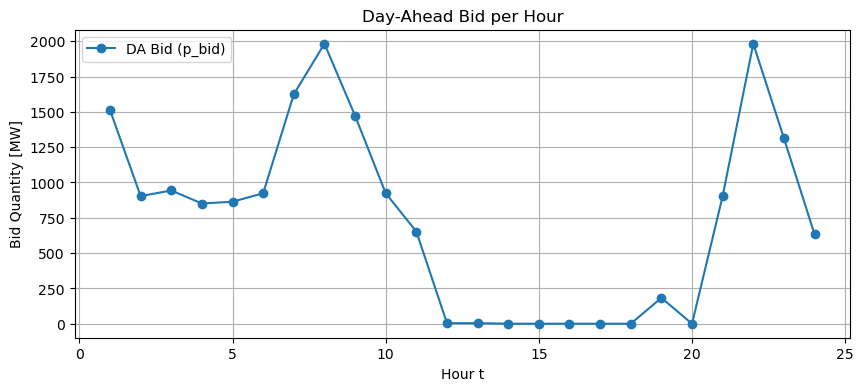

In [79]:
plt.figure(figsize=(10,4))
plt.plot(list(T), [p_bid_sol[t] for t in T], marker="o", label="DA Bid (p_bid)")
plt.xlabel("Hour t")
plt.ylabel("Bid Quantity [MW]")
plt.title("Day-Ahead Bid per Hour")
plt.grid(True)
plt.legend()
plt.show()

In [59]:

for t in T:
    lhs = sum(u[t,b].X * mu_qini[(t,b)] for b in valid_blocks[t]) \
        + sum(qvar[t,b].X for b in valid_blocks[t])
    rhs = p_bid_sol[t]
    print(f"t={t}, lhs={lhs}, rhs={rhs}")

t=1, lhs=1512.3999999999644, rhs=1512.4
t=2, lhs=903.4600000000135, rhs=903.4600000000135
t=3, lhs=943.2600000000226, rhs=943.2600000000226
t=4, lhs=850.9601765888065, rhs=850.9601765888065
t=5, lhs=863.6600000000175, rhs=863.6600000087324
t=6, lhs=923.3600000000165, rhs=923.3600000000165
t=7, lhs=1623.8400000000133, rhs=1623.8400000000133
t=8, lhs=1982.0399999999693, rhs=1982.0399999999693
t=9, lhs=1472.6000000000229, rhs=1472.6
t=10, lhs=923.3600000000165, rhs=923.3600000000165
t=11, lhs=652.7199999999859, rhs=652.7199999999859
t=12, lhs=3.9800000151722394, rhs=3.9800000151722394
t=13, lhs=3.980000015171981, rhs=3.980000015171981
t=14, lhs=0.3505690065012743, rhs=0.3505690065012743
t=15, lhs=0.0, rhs=0.0
t=16, lhs=0.0, rhs=0.0
t=17, lhs=0.0, rhs=0.0
t=18, lhs=0.0, rhs=0.0
t=19, lhs=183.080000000003, rhs=183.080000000003
t=20, lhs=0.0, rhs=0.0
t=21, lhs=903.4600000000135, rhs=903.4600000000135
t=22, lhs=1982.0399999999693, rhs=1982.0399999999693
t=23, lhs=1313.4000000000246, rhs=1313.

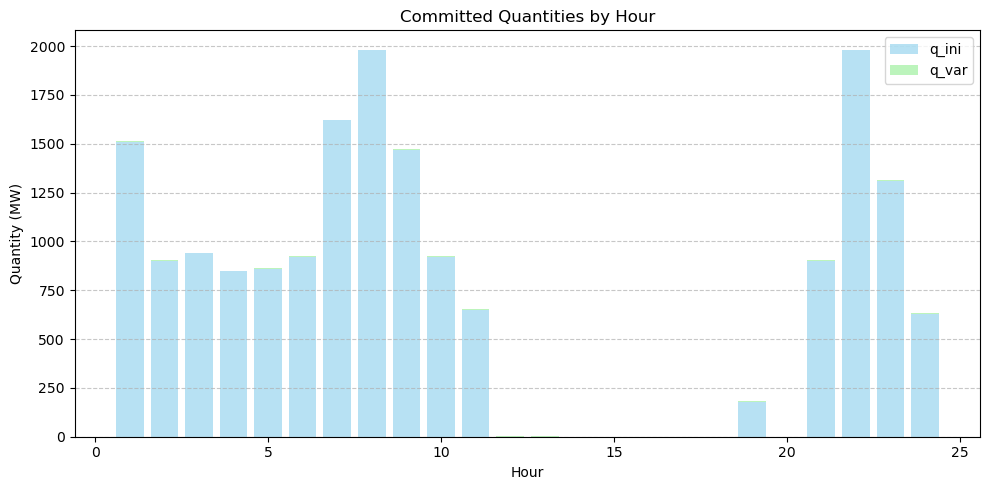

In [60]:
q_ini_hour = []
q_var_hour = []

for t in T:
    qini_sum = sum(u[t,b].X * mu_qini[(t,b)] for b in valid_blocks[t])
    qvar_sum = sum(qvar[t,b].X           for b in valid_blocks[t])
    q_ini_hour.append(qini_sum)
    q_var_hour.append(qvar_sum)

plt.figure(figsize=(10,5))
plt.bar(T, q_ini_hour, color="skyblue", alpha=0.6, label="q_ini")
plt.bar(T, q_var_hour, bottom=q_ini_hour, color="lightgreen", alpha=0.6, label="q_var")

plt.xlabel("Hour")
plt.ylabel("Quantity (MW)")
plt.title("Committed Quantities by Hour")
plt.legend()
plt.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()



In [51]:
scenario = "20250722"
cp_series = [orig_cp.get((scenario, t), np.nan) for t in T]


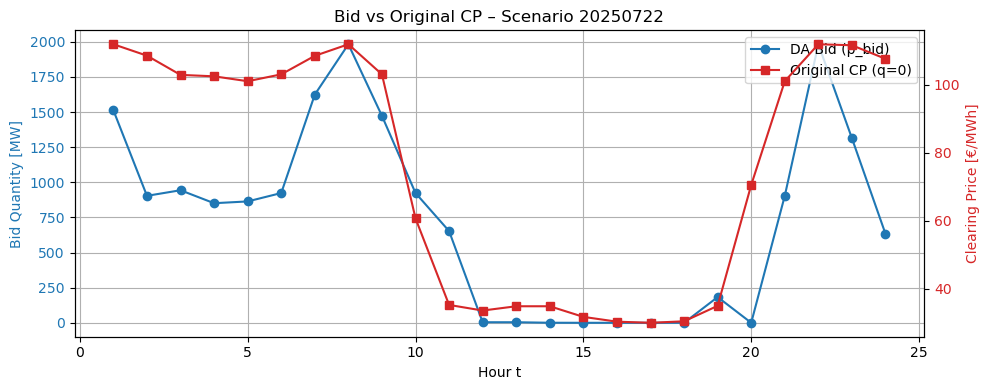

In [52]:
scenario = "20250722"   # 보고 싶은 시나리오 날짜

fig, ax1 = plt.subplots(figsize=(10,4))

# --- Bid (좌측 y축) ---
ax1.plot(T, [p_bid_sol[t] for t in T],
         marker="o", color="tab:blue", label="DA Bid (p_bid)")
ax1.set_xlabel("Hour t")
ax1.set_ylabel("Bid Quantity [MW]", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True)

# --- Original CP (우측 y축) ---
ax2 = ax1.twinx()
cp_series = [orig_cp.get((scenario, t), np.nan) for t in T]  # nan이면 빠짐
ax2.plot(T, cp_series,
         marker="s", color="tab:red", label="Original CP (q=0)")
ax2.set_ylabel("Clearing Price [€/MWh]", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# --- Legend 합치기 ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="upper right")

plt.title(f"Bid vs Original CP – Scenario {scenario}")
plt.tight_layout()
plt.show()



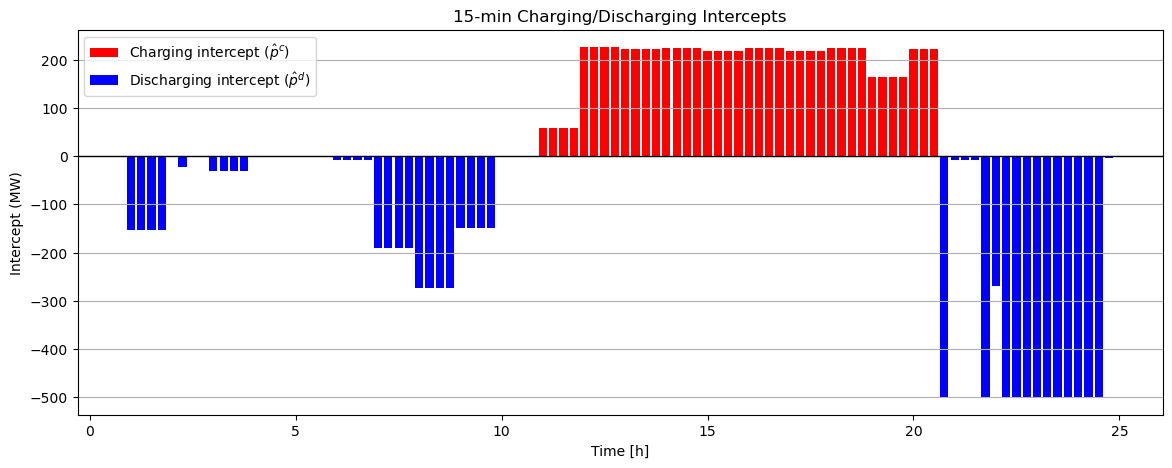

In [40]:
# flatten: (t,j) → 시간축 (1,1)=0.25h, (1,2)=0.5h ... (24,4)=24h
time_axis = [t + (j-1)/4 for t in T for j in J]

# intercept 값 펼치기
p_hat_c_vals = [p_c_mean[(t,j)] for t in T for j in J]
p_hat_d_vals = [p_d_mean[(t,j)] for t in T for j in J]

plt.figure(figsize=(14,5))

plt.bar(time_axis, p_hat_c_vals, width=0.2, color="red", label="Charging intercept ($\hat{p}^c$)")
plt.bar(time_axis, [-v for v in p_hat_d_vals], width=0.2, color="blue", label="Discharging intercept ($\hat{p}^d$)")

plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Time [h]")
plt.ylabel("Intercept (MW)")
plt.title("15-min Charging/Discharging Intercepts")
plt.legend()
plt.grid(True, axis="y")
plt.show()


## RDC에 대한 VSS 구하기

In [24]:
# RDC 시나리오 집합 S(=10개)와 가중치 rho_rdc[s] (균등이면 1/|S|)
# triples[w] = (rdc_s, gen_s, rt_s)
S_rdc = list(range(len(date_range)))   # 10
rho_rdc = {s: 1/len(S_rdc) for s in S_rdc}

# RDC만 평균 (gen/rt는 평균하지 않음)
mu_lambda_RDC = {(t,b): sum(rho_rdc[s]*lambda_da_scen_final[(t,b,s)] for s in S_rdc)
                 for t in T for b in valid_blocks[t]}
mu_qini_RDC   = {(t,b): sum(rho_rdc[s]*qini_scen_final[(t,b,s)]       for s in S_rdc)
                 for t in T for b in valid_blocks[t]}
mu_qmax_RDC   = {(t,b): sum(rho_rdc[s]*qmax_scen_final[(t,b,s)]       for s in S_rdc)
                 for t in T for b in valid_blocks[t]}

In [25]:
for t in T:
    for b in valid_blocks[t]:
        # 아무 시나리오 하나만 골라도 동일 (예: 첫 번째 시나리오 s=0)
        mu_qini_RDC[(t,b)] = qini_scen_final[(t,b,0)]
        mu_qmax_RDC[(t,b)] = qmax_scen_final[(t,b,0)]

In [26]:
# ---------------------------------------
# EV model: RDC만 EV, 나머지는 시나리오 유지
# ---------------------------------------
EV = gp.Model("EV_RDC_only")

# 1단계 변수
u_e   = EV.addVars([(t,b) for t in T for b in valid_blocks[t]], vtype=GRB.BINARY, name="u")
qv_e  = EV.addVars([(t,b) for t in T for b in valid_blocks[t]], lb=0.0, name="qvar")
p_bid_e = EV.addVars(T, lb=0.0, name="p_bid")

u_c_e = EV.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_c")
u_d_e = EV.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_d")
p_hat_c_e = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_c")
p_hat_d_e = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_d")
D_c_e     = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_c")
D_d_e     = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_d")

# 2단계 변수 (w 의존)
p_c_e = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pc_max, name="p_c")
p_d_e = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pd_max, name="p_d")
E_e   = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=E_min, ub=E_max, name="E")
p_b_e = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, name="p_b")

# --- 목적함수 ---
# DA: RDC 평균만 사용
DA_ev = gp.quicksum(
    mu_lambda_RDC[(t,b)] * (u_e[t,b]*mu_qini_RDC[(t,b)] + qv_e[t,b])
    for t in T for b in valid_blocks[t]
)

# RT: GEN/RT는 시나리오별
RT_ev = gp.quicksum(
    rho_w[w] * gp.quicksum(
        rt_big[(t,j,w)] * (p_b_e[t,j,w] - p_bid_e[t]/4.0)
        for j in J
    )
    for w in W for t in T
)

EV.setObjective(DA_ev + RT_ev, GRB.MAXIMIZE)

# --- 제약 ---
for t in T:
    # 블록 하나만 선택
    EV.addConstr(gp.quicksum(u_e[t,b] for b in valid_blocks[t]) == 1)

    # bid 정의
    EV.addConstr(
        p_bid_e[t] == gp.quicksum(u_e[t,b]*mu_qini_RDC[(t,b)] + qv_e[t,b]
                                  for b in valid_blocks[t])
    )

    for b in valid_blocks[t]:
        EV.addConstr(qv_e[t,b] <= mu_qmax_RDC[(t,b)] * u_e[t,b])

# 2단계 (시나리오별 balance, SOC, etc.)
for w in W:
    for t in T:
        for j in J:
            EV.addConstr(
                p_c_e[t,j,w] == u_c_e[t,j] * (p_hat_c_e[t,j] + D_c_e[t,j]*rt_big[(t,j,w)])
            )
            EV.addConstr(
                p_d_e[t,j,w] == u_d_e[t,j] * (p_hat_d_e[t,j] + D_d_e[t,j]*rt_big[(t,j,w)])
            )
            EV.addConstr(
                p_b_e[t,j,w] ==
                (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0)
                + p_d_e[t,j,w] - p_c_e[t,j,w] - p_bid_e[t]/4.0
            )

            prev = (E0 if (t==1 and j==1) else (E_e[(t-1,4,w)] if j==1 else E_e[(t,j-1,w)]))
            EV.addConstr(E_e[t,j,w] == prev + Δt*(eta_c*p_c_e[t,j,w] - p_d_e[t,j,w]/eta_d))

    # bid 경계
    for t in T:
        EV.addConstr(-gp.quicksum(p_c_e[t,j,w] for j in J) <= p_bid_e[t])
        EV.addConstr(p_bid_e[t] <= 1000 + gp.quicksum(p_d_e[t,j,w] for j in J))
model.Params.MIPGap = 0.00000002
EV.optimize()
Z_EV_RDC = EV.ObjVal


Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 244824 rows, 394152 columns and 1030880 nonzeros
Model fingerprint: 0xe7a85ecc
Model has 192000 quadratic constraints
Variable types: 389184 continuous, 4968 integer (4968 binary)
Coefficient statistics:
  Matrix range     [2e-01, 2e+03]
  QMatrix range    [3e-03, 4e+01]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [3e-06, 1e+05]
  Bounds range     [1e+00, 2e+03]
  RHS range        [1e+00, 1e+03]
Presolve removed 27160 rows and 289600 columns
Presolve time: 0.78s
Presolved: 219956 rows, 105596 columns, 814916 nonzeros
Presolved model has 696 SOS constraint(s)
Variable types: 100304 continuous, 5292 integer (5292 binary)
Found heuristic solution: objective 569203.00612

Root relaxation: objective 8.655940e+05, 5397 i

In [ ]:
# EV = gp.Model("EV_RDC_only")

# # 1단계 변수 (RP와 동일)
# u_e   = EV.addVars([(t,b) for t in T for b in valid_blocks[t]], vtype=GRB.BINARY, name="u")
# qv_e  = EV.addVars([(t,b) for t in T for b in valid_blocks[t]], lb=0.0, name="qvar")
# p_bid_e = EV.addVars(T, lb=0.0, name="p_bid")
# u_c_e = EV.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_c")
# u_d_e = EV.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_d")
# p_hat_c_e = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_c")
# p_hat_d_e = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_d")
# D_c_e     = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_c")
# D_d_e     = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_d")

# # 2단계 변수 (w 의존) — 풍력/RT는 그대로 시나리오
# p_c_e = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pc_max, name="p_c")
# p_d_e = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pd_max, name="p_d")
# E_e   = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=E_min, ub=E_max, name="E")
# p_b_e = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, name="p_b")

# # 목적함수
# # DA: RDC 기대치만 사용 → w에 독립 (rho_w 합이 1이면 sum_w 없어도 동일)
# DA_ev = gp.quicksum(mu_lambda_RDC[(t,b)] * (u_e[t,b]*mu_qini_RDC[(t,b)] + qv_e[t,b])
#                     for t in T for b in valid_blocks[t])

# # RT: 기존처럼 시나리오 기대값
# RT_ev = gp.quicksum(
#     rho_w[w] * gp.quicksum(
#         rt_big[(t,j,w)] * (p_b_e[t,j,w] - p_bid_e[t]/4.0)
#         for j in J
#     )
#     for w in W for t in T
# )

# EV.setObjective(DA_ev + RT_ev, GRB.MAXIMIZE)

# # 제약
# for t in T:
#     EV.addConstr(gp.quicksum(u_e[t,b] for b in valid_blocks[t]) == 1, name=f"one_block_{t}")
#     EV.addConstr(p_bid_e[t] == gp.quicksum(u_e[t,b]*mu_qini_RDC[(t,b)] + qv_e[t,b]
#                                            for b in valid_blocks[t]),
#                  name=f"p_bid_def_{t}")
#     for b in valid_blocks[t]:
#         EV.addConstr(qv_e[t,b] <= mu_qmax_RDC[(t,b)] * u_e[t,b], name=f"qvar_max_{t}_{b}")

# # LDR & 균형 & SOC & 경계 — 기존 RP와 동일하지만 pwf_big/rt_big은 그대로 w-의존 사용
# for w in W:
#   for t in T:
#     for j in J:
#       EV.addConstr(p_c_e[t,j,w] == u_c_e[t,j]*(p_hat_c_e[t,j] + D_c_e[t,j]*rt_big[(t,j,w)]))
#       EV.addConstr(p_d_e[t,j,w] == u_d_e[t,j]*(p_hat_d_e[t,j] + D_d_e[t,j]*rt_big[(t,j,w)]))
#       EV.addConstr(p_b_e[t,j,w] ==
#                    (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0) + p_d_e[t,j,w] - p_c_e[t,j,w]
#                    - p_bid_e[t]/4.0)
#       prev = (E0 if (t==1 and j==1) else (E_e[(t-1,4,w)] if j==1 else E_e[(t,j-1,w)]))
#       EV.addConstr(E_e[t,j,w] == prev + Δt*(eta_c*p_c_e[t,j,w] - p_d_e[t,j,w]/eta_d))
#   # bid 경계 (상한 1000은 당신 설정 유지)
#   for t in T:
#       EV.addConstr(-gp.quicksum(p_c_e[t,j,w] for j in J) <= p_bid_e[t])
#       EV.addConstr(p_bid_e[t] <= 1000 + gp.quicksum(p_d_e[t,j,w] for j in J))
# model.Params.MIPGap = 0.0002

# EV.optimize()
# Z_EEV_policy = EV.ObjVal    # 먼저 정책값 저장 (이 값은 EV-정책 하에서의 '설계' 목적)


Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 244824 rows, 394152 columns and 1030880 nonzeros
Model fingerprint: 0xe7a85ecc
Model has 192000 quadratic constraints
Variable types: 389184 continuous, 4968 integer (4968 binary)
Coefficient statistics:
  Matrix range     [2e-01, 2e+03]
  QMatrix range    [3e-03, 4e+01]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [3e-06, 1e+05]
  Bounds range     [1e+00, 2e+03]
  RHS range        [1e+00, 1e+03]
Presolve removed 27160 rows and 289600 columns
Presolve time: 0.76s
Presolved: 219956 rows, 105596 columns, 814916 nonzeros
Presolved model has 696 SOS constraint(s)
Variable types: 100304 continuous, 5292 integer (5292 binary)
Found heuristic solution: objective 569203.00612

Root relaxation: objective 8.655940e+05, 5397 i

In [27]:
EEV = gp.Model("EEV_RDC_eval")

# 2단계만 변수
p_c2 = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pc_max)
p_d2 = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pd_max)
E2   = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=E_min, ub=E_max)
p_b2 = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0)

# EV의 1단계 해 고정값 사용
DA_eval = gp.quicksum(
    rho_w[w] * gp.quicksum(
        lambda_da_big[(t,b,w)] * (u_e[t,b].X * qini_big[(t,b,w)] + qv_e[t,b].X)
        for b in valid_blocks[t] if (t,b,w) in lambda_da_big
    )
    for w in W for t in T
)
RT_eval = gp.quicksum(
    rho_w[w] * gp.quicksum(
        rt_big[(t,j,w)] * (p_b2[t,j,w] - p_bid_e[t].X/4.0)
        for j in J
    )
    for w in W for t in T
)
EEV.setObjective(DA_eval + RT_eval, GRB.MAXIMIZE)

# LDR/균형/SOC/경계 — EV의 u_c,u_d,p_hat,D,p_bid 를 **값**으로 사용
for w in W:
  for t in T:
    for j in J:
      EEV.addConstr(p_c2[t,j,w] == u_c_e[t,j].X*(p_hat_c_e[t,j].X + D_c_e[t,j].X*rt_big[(t,j,w)]))
      EEV.addConstr(p_d2[t,j,w] == u_d_e[t,j].X*(p_hat_d_e[t,j].X + D_d_e[t,j].X*rt_big[(t,j,w)]))
      EEV.addConstr(p_b2[t,j,w] ==
                    (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0) + p_d2[t,j,w] - p_c2[t,j,w]
                    - p_bid_e[t].X/4.0)
      prev = (E0 if (t==1 and j==1) else (E2[(t-1,4,w)] if j==1 else E2[(t,j-1,w)]))
      EEV.addConstr(E2[t,j,w] == prev + Δt*(eta_c*p_c2[t,j,w] - p_d2[t,j,w]/eta_d))
  for t in T:
      EEV.addConstr(-gp.quicksum(p_c2[t,j,w] for j in J) <= p_bid_e[t].X)
      EEV.addConstr(p_bid_e[t].X <= 1000 + gp.quicksum(p_d2[t,j,w] for j in J))
model.Params.MIPGap = 0.00000002
EEV.optimize()
Z_EEV = EEV.ObjVal

Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 432000 rows, 384000 columns and 1055000 nonzeros
Model fingerprint: 0x0b0404b4
Coefficient statistics:
  Matrix range     [2e-01, 1e+00]
  Objective range  [3e-06, 4e-02]
  Bounds range     [5e+02, 2e+03]
  RHS range        [3e-14, 2e+03]
Presolve removed 432000 rows and 384000 columns
Presolve time: 0.13s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    8.6555421e+05   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.24 seconds (0.32 work units)
Optimal objective  8.655542133e+05


In [28]:
VSS_RDC = Z_RP - Z_EEV
print(f"Z_RP    = {Z_RP:,.2f}")
print(f"Z_EEV   = {Z_EEV:,.2f}")
print(f"VSS(RDC)= {VSS_RDC:,.2f}")

Z_RP    = 865,572.21
Z_EEV   = 865,554.21
VSS(RDC)= 17.99


## 전체에 대한 VSS

In [29]:
# --- 기대값 파라미터 ---
mu_lambda = {(t,b): sum(rho_w[w] * lambda_da_big[(t,b,w)] for w in W if (t,b,w) in lambda_da_big)
             for t in T for b in valid_blocks[t]}
mu_qini   = {(t,b): qini_big[(t,b,0)]  for t in T for b in valid_blocks[t]}   # 상수
mu_qmax   = {(t,b): qmax_big[(t,b,0)]  for t in T for b in valid_blocks[t]}   # 상수
mu_pwf    = {(i,t): sum(rho_w[w] * pwf_big[(i,t,w)] for w in W)
             for i in I for t in T}
mu_rt     = {(t,j): sum(rho_w[w] * rt_big[(t,j,w)] for w in W)
             for t in T for j in J}

In [33]:
EV = gp.Model("EV_full")

# 1단계 변수
u   = EV.addVars([(t,b) for t in T for b in valid_blocks[t]], vtype=GRB.BINARY)
qv  = EV.addVars([(t,b) for t in T for b in valid_blocks[t]], lb=0.0)
p_bid = EV.addVars(T, lb=0.0)

u_c = EV.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY)
u_d = EV.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY)
p_hat_c = EV.addVars([(t,j) for t in T for j in J], lb=0.0)
p_hat_d = EV.addVars([(t,j) for t in T for j in J], lb=0.0)
D_c     = EV.addVars([(t,j) for t in T for j in J], lb=0.0)
D_d     = EV.addVars([(t,j) for t in T for j in J], lb=0.0)

# 2단계 변수 (결정론 → w 없음)
p_c = EV.addVars([(t,j) for t in T for j in J], lb=0.0, ub=pc_max)
p_d = EV.addVars([(t,j) for t in T for j in J], lb=0.0, ub=pd_max)
E   = EV.addVars([(t,j) for t in T for j in J], lb=E_min, ub=E_max)
p_b = EV.addVars([(t,j) for t in T for j in J], lb=0.0)

# 목적함수
DA_ev = gp.quicksum(mu_lambda[(t,b)] * (u[t,b]*mu_qini[(t,b)] + qv[t,b])
                    for t in T for b in valid_blocks[t])
RT_ev = gp.quicksum(mu_rt[(t,j)] * (p_b[t,j] - p_bid[t]/4.0)
                    for t in T for j in J)
EV.setObjective(DA_ev + RT_ev, GRB.MAXIMIZE)

# 제약식들
for t in T:
    EV.addConstr(gp.quicksum(u[t,b] for b in valid_blocks[t]) == 1)
    EV.addConstr(p_bid[t] == gp.quicksum(u[t,b]*mu_qini[(t,b)] + qv[t,b] for b in valid_blocks[t]))
    for b in valid_blocks[t]:
        EV.addConstr(qv[t,b] <= mu_qmax[(t,b)] * u[t,b])

for t in T:
    for j in J:
        prev = (E0 if (t==1 and j==1) else (E[(t-1,4)] if j==1 else E[(t,j-1)]))
        EV.addConstr(E[(t,j)] == prev + Δt*(eta_c*p_c[(t,j)] - p_d[(t,j)]/eta_d))
        EV.addConstr(p_b[(t,j)] == (gp.quicksum(mu_pwf[(i,t)] for i in I)/4.0)
                                   + p_d[(t,j)] - p_c[(t,j)] - p_bid[t]/4.0)

        EV.addConstr(p_c[(t,j)] <= pc_max*u_c[(t,j)])
        EV.addConstr(p_d[(t,j)] <= pd_max*u_d[(t,j)])
    EV.addConstr(u_c[(t,j)] + u_d[(t,j)] <= 1)

    EV.addConstr(-gp.quicksum(p_c[(t,j)] for j in J) <= p_bid[t])
    EV.addConstr(p_bid[t] <= 1000 + gp.quicksum(p_d[(t,j)] for j in J))
model.Params.MIPGap = 0.00000002
EV.optimize()
Z_EV = EV.ObjVal


Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 5280 rows, 10536 columns and 25319 nonzeros
Model fingerprint: 0x2e7d3e10
Variable types: 5568 continuous, 4968 integer (4968 binary)
Coefficient statistics:
  Matrix range     [2e-01, 2e+03]
  Objective range  [1e-03, 1e+05]
  Bounds range     [1e+00, 2e+03]
  RHS range        [1e+00, 1e+03]
Presolve removed 358 rows and 950 columns
Presolve time: 0.03s
Presolved: 4922 rows, 9586 columns, 24584 nonzeros
Variable types: 4946 continuous, 4640 integer (4640 binary)
Found heuristic solution: objective 514634.58773
Found heuristic solution: objective 658198.14633

Root relaxation: objective 8.876373e+05, 2683 iterations, 0.02 seconds (0.08 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Ex

In [35]:
# ===============================
# EEV (정석) — EV 1단계 해 평가
# ===============================
EEV = gp.Model("EEV_full")

# 2단계 변수 (시나리오 의존)
p_c2 = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pc_max, name="p_c")
p_d2 = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pd_max, name="p_d")
E2   = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=E_min,  ub=E_max,  name="E")
p_b2 = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0,               name="p_b")

# -----------------------
# 목적함수 구성
# -----------------------
# DA(시나리오별 가격으로 평가) : 고정된 u, qv와 시나리오별 qini_big/λ 사용
DA_eval = gp.quicksum(
    rho_w[w] * gp.quicksum(
        gp.quicksum(
            (lambda_da_big[(t,b,w)]
             * (u[t,b].X * qini_big[(t,b,w)] + qv[t,b].X))
            for b in valid_blocks[t]
            if (t,b,w) in lambda_da_big and (t,b,w) in qini_big
        )
        for t in T
    )
    for w in W
)

# RT(시나리오 기대값) : 2단계만 재최적화
RT_eval = gp.quicksum(
    rho_w[w] * gp.quicksum(
        rt_big[(t,j,w)] * (p_b2[(t,j,w)] - p_bid[t].X/4.0)
        for t in T for j in J
    )
    for w in W
)

EEV.setObjective(DA_eval + RT_eval, GRB.MAXIMIZE)

# -----------------------
# 제약식 (1단계 해 고정 반영)
# -----------------------
for w in W:
    for t in T:
        for j in J:
            # LDR: u_c/u_d, p_hat, D는 EV 1단계 해의 값 고정 사용
            EEV.addConstr(
                p_c2[(t,j,w)] == u_c[(t,j)].X * (p_hat_c[(t,j)].X + D_c[(t,j)].X * rt_big[(t,j,w)])
            )
            EEV.addConstr(
                p_d2[(t,j,w)] <= u_d[(t,j)].X * (p_hat_d[(t,j)].X + D_d[(t,j)].X * rt_big[(t,j,w)])
            )
            # 실시간 전력수지
            EEV.addConstr(
                p_b2[(t,j,w)] ==
                (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0) + p_d2[(t,j,w)] - p_c2[(t,j,w)]
                - p_bid[t].X/4.0
            )
            # SOC 전이
            prev = (E0 if (t == 1 and j == 1)
                    else (E2[(t-1,4,w)] if j == 1 else E2[(t,j-1,w)]))
            EEV.addConstr(
                E2[(t,j,w)] == prev + Δt*(eta_c*p_c2[(t,j,w)] - p_d2[(t,j,w)]/eta_d)
            )

        # DA-RT 경계(1단계 p_bid 고정 값 사용)
        EEV.addConstr(-gp.quicksum(p_c2[(t,j,w)] for j in J) <= p_bid[t].X)
        EEV.addConstr(p_bid[t].X <= 1000 + gp.quicksum(p_d2[(t,j,w)] for j in J))

# (필요시) 동시 충방전 금지 조건은 EV에서 이미 u_c/u_d가 고정되어 있어
# 자연스럽게 p_c2/p_d2 Big-M로 제한됨. 추가로 넣고 싶으면 아래처럼 가능:
for t in T:
    for j in J:
        for w in W:
            EEV.addConstr(p_c2[(t,j,w)] <= pc_max * u_c[(t,j)].X)
            EEV.addConstr(p_d2[(t,j,w)] <= pd_max * u_d[(t,j)].X)
model.Params.MIPGap = 0.00000002
# 풀기
EEV.optimize()
Z_EEV = EEV.ObjVal

print(f"Z_EEV (full-scenario evaluation of EV policy) = {Z_EEV:.6f}")


Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 624000 rows, 384000 columns and 1247000 nonzeros
Model fingerprint: 0x683213f0
Coefficient statistics:
  Matrix range     [2e-01, 1e+00]
  Objective range  [3e-06, 4e-02]
  Bounds range     [5e+02, 2e+03]
  RHS range        [5e-01, 2e+03]
Presolve removed 479200 rows and 246700 columns
Presolve time: 0.09s

Solved in 0 iterations and 0.09 seconds (0.08 work units)
Infeasible or unbounded model


AttributeError: Unable to retrieve attribute 'ObjVal'

확인 디버깅

In [66]:
negatives = [(t,b,val) for (t,b), val in mu_qmax_RDC.items() if val < -1e-6]
print("음수 mu_qmax_RDC 개수:", len(negatives))
if negatives:
    for t,b,val in negatives[:10]:
        print(f"t={t}, b={b}, mu_qmax={val}")

음수 mu_qmax_RDC 개수: 0


In [ ]:
spread = {}
for t in T:
    for b in valid_blocks[t]:
        vals = [qmax_scen_final[(t,b,s)] for s in S_rdc]
        spread[(t,b)] = (min(vals), max(vals), np.mean(vals))

for (t,b), (vmin,vmax,vmean) in list(spread.items())[:10]:
    print(f"(t={t}, b={b}): min={vmin}, max={vmax}, mean={vmean}")


(t=1, b=0): min=3.98, max=3.98, mean=3.9799999999999995
(t=1, b=1): min=3.98, max=3.98, mean=3.9799999999999995
(t=1, b=2): min=3.98, max=3.98, mean=3.9799999999999995
(t=1, b=3): min=3.98, max=3.98, mean=3.9799999999999995
(t=1, b=4): min=3.980000000000004, max=3.980000000000004, mean=3.980000000000004
(t=1, b=5): min=3.980000000000004, max=3.980000000000004, mean=3.980000000000004
(t=1, b=6): min=3.979999999999997, max=3.979999999999997, mean=3.979999999999997
(t=1, b=7): min=3.980000000000004, max=3.980000000000004, mean=3.980000000000004
(t=1, b=8): min=3.980000000000004, max=3.980000000000004, mean=3.980000000000004
(t=1, b=9): min=3.980000000000004, max=3.980000000000004, mean=3.980000000000004


In [68]:
total_rho_w = sum(rho_w.values()) if isinstance(rho_w, dict) else sum(rho_w)
print("∑ rho_w =", total_rho_w)


∑ rho_w = 1.0000000000000007


In [69]:
missing = []
for w in W:
    for t in T:
        for b in valid_blocks[t]:
            if (t,b,w) not in lambda_da_big:
                missing.append((t,b,w))
print("lambda_da_big에 없는 (t,b,w) 개수:", len(missing))
if missing:
    print("예시:", missing[:10])


lambda_da_big에 없는 (t,b,w) 개수: 0


In [72]:
# 스칼라 지표
# Z_RP       = RP.ObjVal
Z_EV_RDC   = EV.ObjVal
Z_EEV_RDC  = EEV.ObjVal
VSS_RDC    = Z_RP - Z_EEV_RDC
RelVSS_RDC = (Z_RP - Z_EEV_RDC) / (abs(Z_RP) + 1e-6)
print(f"RP={Z_RP:.3f}, EV_RDC={Z_EV_RDC:.3f}, EEV_RDC={Z_EEV_RDC:.3f}, "
      f"VSS_RDC={VSS_RDC:.3f} ({100*RelVSS_RDC:.2f}%)")


RP=861935.090, EV_RDC=862063.758, EEV_RDC=862063.758, VSS_RDC=-128.668 (-0.01%)
